# Projektrapport – Optimering och investeringsanalys för hushållsbatteri med AI-styrning

Elmarknaden i Sverige är rena "vilda västern" och det utlovas mycket, men hur ser verkligheten ut bakom de siffror som presenteras? 

Min idé med projektet var att samla in data (IoT såväl som affärsdata), se hur det faktiska utfallet varit utan batteri och skapa en simulering för att se hur det kunde ha sett ut om ett hushållsbatteri kunde utjämna pristopparna. Därefter är planen att skapa en AI-modell för styrning av batteriet baserat på de 30 månader timvis data jag sammanställt, i kombination med ytterligare IoT-data från SMHIs sensorer via deras öppna API.

1. Insamling av data
De data jag ville åt fanns dels hos min elleverantör (Halmstad Energi och Miljö) och dels hos leverantören av solpanelerna. Affärsdata i form av såld och köpt el kunde ganska enkelt hämtas via elleverantörens webbgränssnitt. 

Det uppstod dock problem att extrahera timvis historisk data direkt från växelriktaren på grund av begränsningar i Solis Clouds användargränssnitt (låst till dygnsdata vid längre tidsspann). Jag fick därför hämta IoT-data "på djupet" i deras system via en API-nyckel och en egen kodning.

Till detta laddade jag även ned data om soltimmar från Nasa Power, en satellitbaserad tjänst som mäter solinstrålning timvis. Detta för att kunna verifiera min egen solproduktion och ha som stöd för en AI-modell.

Efter lite massering av mina olika CSV-filer för att bl.a. synka tidsstämplar hade jag till sist en komplett fil med data för de 30 månader jag valt som tidsperiod.

In [ ]:
import hmac
import hashlib
import base64
import json
import requests
import time
import os
import pandas as pd
from datetime import datetime, timezone, timedelta
from dotenv import load_dotenv

# Läs in miljövariabler från .env
load_dotenv()
API_ID     = os.getenv("API_ID_SOLIS")
API_SECRET = os.getenv("API_SECRET_SOLIS")

INVERTER_SN = "1805040227120162"
BASE_URL    = "https://www.soliscloud.com:13333"

In [ ]:
def get_solis_headers(path: str, body_dict: dict) -> tuple[dict, str]:
    """Skapar HMAC-SHA1-signerade headers för Solis Cloud API."""
    body_str    = json.dumps(body_dict, separators=(",", ":"))
    md5_hash    = hashlib.md5(body_str.encode("utf-8")).digest()
    content_md5 = base64.b64encode(md5_hash).decode("utf-8")

    now      = datetime.now(timezone.utc)
    date_str = now.strftime("%a, %d %b %Y %H:%M:%S GMT")

    content_type = "application/json;charset=UTF-8"
    sign_ctype   = "application/json"          # Solis signerar utan charset
    sign_str     = "\n".join(["POST", content_md5, sign_ctype, date_str, path])

    hashed = hmac.new(API_SECRET.encode("utf-8"),
                      sign_str.encode("utf-8"),
                      hashlib.sha1).digest()
    sign   = base64.b64encode(hashed).decode("utf-8")

    headers = {
        "Content-MD5":   content_md5,
        "Content-Type":  content_type,
        "Date":          date_str,
        "Authorization": f"API {API_ID}:{sign}",
    }
    return headers, body_str


def fetch_day(target_date: str, tz_offset: int) -> pd.DataFrame | None:
    """
    Hämtar 5-minutersdata för ett dygn från Solis Cloud API.

    Args:
        target_date: Datum som sträng, t.ex. '2025-07-01'
        tz_offset:   UTC-offset (2 = CEST sommartid, 1 = CET vintertid)

    Returns:
        DataFrame med rådata, eller None om anropet misslyckas.
    """
    path    = "/v1/api/inverterDay"
    payload = {
        "sn":       INVERTER_SN,
        "money":    "EUR",
        "time":     target_date,
        "timeZone": tz_offset,
    }
    headers, body = get_solis_headers(path, payload)
    try:
        res  = requests.post(BASE_URL + path, headers=headers, data=body, timeout=15)
        data = res.json()
        if str(data.get("code")) == "0" and data.get("data"):
            return pd.DataFrame(data["data"])
    except Exception as e:
        print(f"  Fel vid {target_date}: {e}")
    return None

In [ ]:
def fetch_solis_year(target_year: int) -> pd.DataFrame | None:
    """
    Hämtar all tillgänglig data för ett kalenderår och sparar
    timvisa medelvärden (kW) till CSV.

    Args:
        target_year: Årtalet som ska hämtas, t.ex. 2024

    Returns:
        DataFrame med timvisa medelvärden, eller None.
    """
    start_date = datetime(target_year, 1, 1)
    end_date   = min(datetime(target_year, 12, 31),
                     datetime.now() - timedelta(days=1))

    # Datumgränser för sommartid i Sverige (ungefärliga)
    dst_start = datetime(target_year,  3, 25)
    dst_end   = datetime(target_year, 10, 25)

    all_days     = []
    current_date = start_date

    print(f"--- Hämtar data för {target_year} ({start_date.date()} → {end_date.date()}) ---")

    while current_date <= end_date:
        date_str  = current_date.strftime("%Y-%m-%d")
        tz_offset = 2 if dst_start <= current_date < dst_end else 1

        df_day = fetch_day(date_str, tz_offset)
        if df_day is not None:
            all_days.append(df_day)
            print(f"  {date_str} ✓ ({len(df_day)} punkter)", end="\r")

        current_date += timedelta(days=1)
        time.sleep(0.3)   # Respektera API:ets rate-limit

    if not all_days:
        print(f"Ingen data hittades för {target_year}.")
        return None

    full_df = pd.concat(all_days, ignore_index=True)

    # Konvertera timestamp (ms UTC) → svensk lokal tid
    full_df["timestamp"] = (
        pd.to_datetime(full_df["dataTimestamp"].astype(float), unit="ms", utc=True)
        .dt.tz_convert("Europe/Stockholm")
        .dt.tz_localize(None)
    )
    full_df["pac"] = pd.to_numeric(full_df["pac"], errors="coerce")
    full_df.set_index("timestamp", inplace=True)

    # Aggregera till timvisa medelvärden (kW)
    hourly_df = full_df["pac"].resample("1h").mean().reset_index()
    hourly_df.columns = ["timestamp", "avg_power_kw"]

    filename = f"solisdata_{target_year}_local.csv"
    hourly_df.to_csv(filename, index=False)
    print(f"\n✅ {target_year}: {len(all_days)} dagar → sparad som '{filename}'")
    return hourly_df


# --- Kör för önskade år ---
df_2023 = fetch_solis_year(2023)
df_2024 = fetch_solis_year(2024)
df_2025 = fetch_solis_year(2025)

In [ ]:
import pandas as pd
from io import StringIO
import numpy as np
from datetime import datetime

# ── 1. INLÄSNINGSFUNKTIONER ───────────────────────────────────────────────────

def load_el_data(filenames):
    """Läser el-filer från leverantör (semikolon-separerade, komma-decimal)."""
    dfs = []
    for f in filenames:
        print(f"Bearbetar el-leverantörsdata: {f}")
        df = pd.read_csv(f, sep=";", decimal=",", encoding="utf-8")
        df["timestamp"] = pd.to_datetime(df["Datum"])
        df = df.rename(columns={
            "El kWh":        "grid_import_kwh",
            "Produktion":    "grid_export_kwh",
            "Totalt re/kWh": "price_total_ore",
        })
        dfs.append(df[["timestamp", "grid_import_kwh", "grid_export_kwh", "price_total_ore"]])
    return pd.concat(dfs).drop_duplicates("timestamp")


def load_solis_data(filenames):
    """Läser Solis-inverterdata och konverterar W → kWh (timvärden)."""
    dfs = []
    for f in filenames:
        print(f"Bearbetar Solis-data: {f}")
        df = pd.read_csv(f)
        df["timestamp"] = pd.to_datetime(df["timestamp"])
        # avg_power_kw är medel-kW per timme → kWh per timme
        df["total_production_kwh"] = pd.to_numeric(df["avg_power_kw"], errors="coerce") / 1000.0
        dfs.append(df[["timestamp", "total_production_kwh"]])
    return pd.concat(dfs).drop_duplicates("timestamp")


def load_nasa_data(filename):
    """Läser NASA POWER-data och justerar från fast UTC+1 till svensk lokaltid."""
    print(f"Bearbetar NASA-väderdata: {filename}")
    with open(filename, "r") as f:
        lines = f.readlines()
    start_idx = next(i for i, line in enumerate(lines) if line.startswith("YEAR"))
    df = pd.read_csv(StringIO("".join(lines[start_idx:])))
    df["timestamp"] = pd.to_datetime(
        df[["YEAR", "MO", "DY", "HR"]].rename(
            columns={"YEAR": "year", "MO": "month", "DY": "day", "HR": "hour"}
        )
    )
    # NASA LST = fast UTC+1; konvertera till Europe/Stockholm för sommar/vintertid
    df["timestamp"] = (
        df["timestamp"]
        .dt.tz_localize("Etc/GMT-1")
        .dt.tz_convert("Europe/Stockholm")
        .dt.tz_localize(None)
    )
    df = df.rename(columns={"ALLSKY_SFC_SW_DWN": "irradiance_wm2"})
    return df[["timestamp", "irradiance_wm2"]]


# ── 2. LADDA DATA ────────────────────────────────────────────────────────────

el_files = [
    "El - Erlandsliden 15 B, Halmstad 2023 - halvår.csv",
    "El - Erlandsliden 15 B, Halmstad 2024.csv",
    "El - Erlandsliden 15 B, Halmstad 2025.csv",
]
solis_files = [
    "solisdata_2023_local.csv",
    "solisdata_2024_local.csv",
    "solisdata_2025_local.csv",
]
nasa_file = "POWERPointHourly_20230701_20260323_056d66N_012d81E_LST.csv"

df_grid   = load_el_data(el_files)
df_inv    = load_solis_data(solis_files)
df_weather = load_nasa_data(nasa_file)

# ── 3. MERGE TILL MASTER ─────────────────────────────────────────────────────

master_df = (
    df_grid
    .merge(df_inv,     on="timestamp", how="left")
    .merge(df_weather, on="timestamp", how="left")
)

# Fyll nattimmarnas saknade produktion med 0
master_df["total_production_kwh"] = master_df["total_production_kwh"].fillna(0)

# ── 4. BERÄKNA ENERGIFLÖDEN ──────────────────────────────────────────────────

# A. Egenförbrukning = Produktion − Export (vad som aldrig lämnade huset)
master_df["self_consumption_kwh"] = (
    master_df["total_production_kwh"] - master_df["grid_export_kwh"]
).clip(lower=0)

# B. Total huslast = Köpt el + Egenförbrukning
master_df["total_house_load_kwh"] = (
    master_df["grid_import_kwh"] + master_df["self_consumption_kwh"]
)

# C. Nettobalans (+ = överskott, − = underskott)
master_df["net_balance_kwh"] = (
    master_df["total_production_kwh"] - master_df["total_house_load_kwh"]
)

# ── 5. FEATURE ENGINEERING ───────────────────────────────────────────────────

master_df["hour"]      = master_df["timestamp"].dt.hour
master_df["weekday"]   = master_df["timestamp"].dt.weekday
master_df["is_weekend"] = (master_df["weekday"] >= 5).astype(int)
master_df["month"]     = master_df["timestamp"].dt.month
master_df["season"]    = master_df["month"].map({
    12: "winter", 1: "winter", 2: "winter",
     3: "spring", 4: "spring", 5: "spring",
     6: "summer", 7: "summer", 8: "summer",
     9: "autumn", 10: "autumn", 11: "autumn",
})
master_df["hour_sin"] = np.sin(2 * np.pi * master_df["hour"] / 24)
master_df["hour_cos"] = np.cos(2 * np.pi * master_df["hour"] / 24)

# ── 6. TVÄTTA OCH SPARA ──────────────────────────────────────────────────────

# Rensa negativa energivärden och saknade priser
energy_cols = ["grid_import_kwh", "grid_export_kwh", "total_production_kwh",
               "self_consumption_kwh", "total_house_load_kwh"]
master_df[energy_cols] = master_df[energy_cols].clip(lower=0)
master_df["irradiance_wm2"] = master_df["irradiance_wm2"].replace(-999, np.nan).clip(lower=0)
master_df["price_total_ore"] = master_df["price_total_ore"].fillna(0)

master_df = master_df.sort_values("timestamp").reset_index(drop=True)
master_df.to_csv("master_energy_data.csv", index=False)

print(f"✅ master_energy_data.csv skapad – {len(master_df)} rader, {len(master_df.columns)} kolumner")
print(f"Datumintervall: {master_df['timestamp'].min()} → {master_df['timestamp'].max()}")
corr = master_df["total_production_kwh"].corr(master_df["irradiance_wm2"])
print(f"Synk-kontroll – korrelation Sol/Irradians: {corr:.2f}")
display(master_df.head())

Visualisering av energiprofilen 07-23 till 12-25.

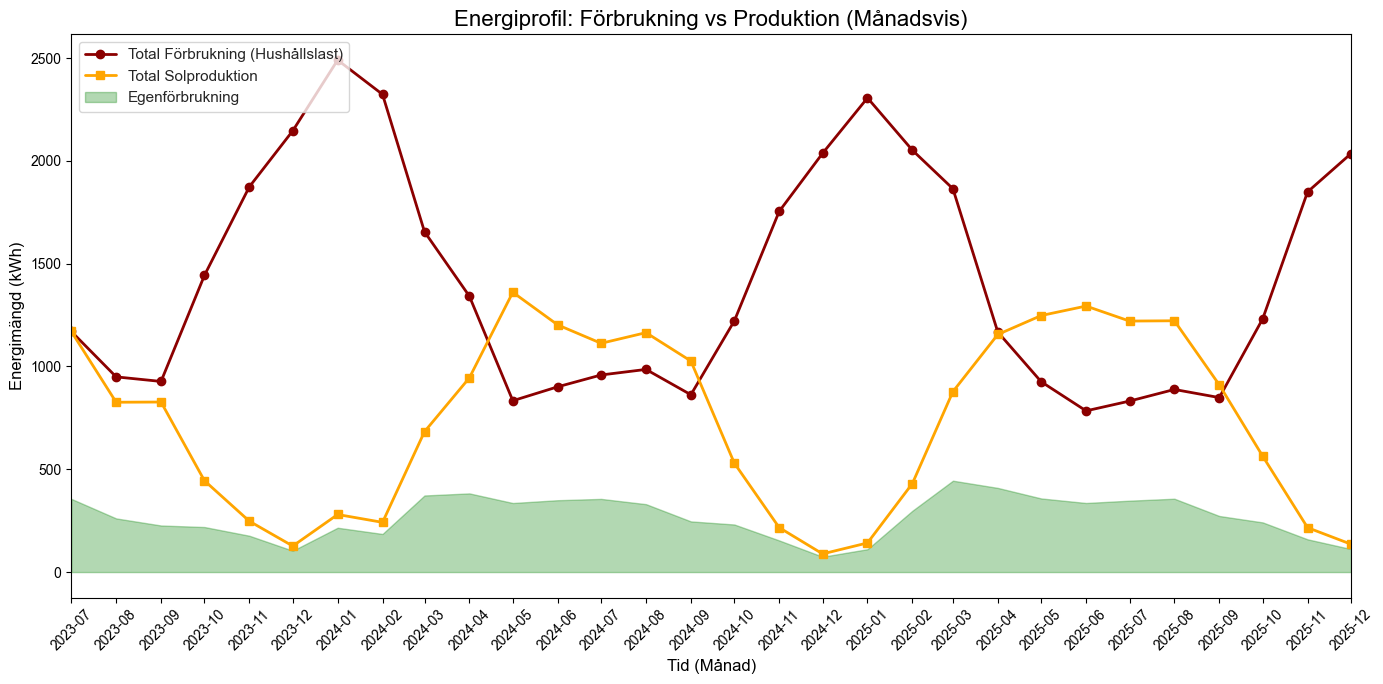

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# 1. Ladda in data
path = r"Datainsamling/Del 3 - Data för projektet/master_energy_data_cleaned.csv"
df = pd.read_csv(path, parse_dates=['timestamp'])
df.set_index('timestamp', inplace=True)

# 2. Aggregera data per månad
monthly_data = df.resample('MS').agg({
    'grid_import_kwh': 'sum',
    'grid_export_kwh': 'sum',
    'total_production_kwh': 'sum',
    'total_house_load_kwh': 'sum',
    'self_consumption_kwh': 'sum'
})

# 3. Visualisering
fig, ax = plt.subplots(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# Förbrukning och produktion
ax.plot(monthly_data.index, monthly_data['total_house_load_kwh'], 
         label='Total Förbrukning (Hushållslast)', marker='o', linewidth=2, color='darkred')
ax.plot(monthly_data.index, monthly_data['total_production_kwh'], 
         label='Total Solproduktion', marker='s', linewidth=2, color='orange')

# Egenförbrukning
ax.fill_between(monthly_data.index, monthly_data['self_consumption_kwh'], 
                 alpha=0.3, label='Egenförbrukning', color='green')

ax.set_xlim(monthly_data.index.min(), monthly_data.index.max())

# Snygga till
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

# -----------------------------------------------------------------

plt.title('Energiprofil: Förbrukning vs Produktion (Månadsvis)', fontsize=16)
plt.xlabel('Tid (Månad)', fontsize=12)
plt.ylabel('Energimängd (kWh)', fontsize=12)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


2. Beslutsstöd för investering i hushållsbatteri
Eftersom det har talats mycket om att komplettera solpaneler med batteri för att lagra oanvänd el och sedan använda den när solen gått ned i stället för att köpa el så gör jag en simulering. 

Det här visar hur det *kunde ha sett ut* om jag redan haft ett batteri med en smart styrning. 


In [8]:
import pandas as pd
import numpy as np

# 1. PARAMETRAR 
PATH        = r"Datainsamling/Del 3 - Data för projektet/master_energy_data_cleaned.csv"
MOMS        = 1.25
TAX_FEES_KR = 0.7075  # 70,75 öre (Energiskatt + Nätavgift + Elhandel rörlig inkl moms)
SELL_ADJUST = 0.029   # 2,9 öre (Nätnytta – balanskostnad)
CAPACITY    = 18.0
EFFICIENCY  = 0.9
COST_18KWH  = 83939

# 2. LADDA DATA
df = pd.read_csv(PATH, parse_dates=['timestamp'])
df = df.sort_values('timestamp').set_index('timestamp')

# 3. SMART SIMULERING (24h Rullande Lookahead)
def simulate_smart_lookahead(df_input, cap, eff=0.9):
    soc = 0.0
    total_profit = 0.0
    
    # Förberedelse: Hitta alla timmar där solproduktion > förbrukning
    solar_potential = df_input['total_production_kwh'] > df_input['total_house_load_kwh']
    
    # Loopa igenom varje timme
    for i in range(len(df_input)):
        current_ts = df_input.index[i]
        row = df_input.iloc[i]
        
        # Spotpris och marginaler för denna timme
        spot = row['price_total_ore'] / 100
        buy_p = spot * MOMS + TAX_FEES_KR
        sell_p = spot + SELL_ADJUST
        
        # Titta framåt: När börjar solen skina nästa gång?
        # Vi tittar 24h framåt
        future_24h = solar_potential.iloc[i : i+24]
        if future_24h.any():
            next_solar_ts = future_24h[future_24h].index[0]
            hours_to_solar = (next_solar_ts - current_ts).total_seconds() / 3600
        else:
            hours_to_solar = 24
            
        # --- LADDNING (SOL) ---
        if row['grid_export_kwh'] > 0:
            charge = min(row['grid_export_kwh'], (cap - soc) / eff)
            soc += charge * eff
            total_profit -= charge * sell_p # Förlorad säljintäkt
            
        # --- SMART URLADDNING ---
        elif row['grid_import_kwh'] > 0 and soc > 0:
            # Hitta maxpriset mellan NU och nästa soltillfälle
            window_to_solar = df_input.iloc[i : i + int(hours_to_solar) + 1]
            max_price_in_window = (window_to_solar['price_total_ore'] / 100).max()
            
            # Beslutslogik:
            # 1. Är det dyraste timmen innan nästa laddning? (Optimera vinst)
            is_peak = spot >= max_price_in_window
            
            # 2. Måste vi börja tömma för att hinna bli tomma till solen kommer? (Säkra plats)
            # Vi antar att huset kan svälja ca 1.5 kWh per timme
            needs_to_empty = soc > (hours_to_solar * 1.5)
            
            if is_peak or needs_to_empty:
                discharge = min(row['grid_import_kwh'], soc)
                soc -= discharge
                total_profit += discharge * buy_p # Sparad utgift
                
    return total_profit

# 4. KÖR OCH PRESENTERA
vinst_18 = simulate_smart_lookahead(df, CAPACITY)
total_years = (df.index.max() - df.index.min()).days / 365.25
annual_vinst = vinst_18 / total_years

print(f"--- Batterisimulering med 24h rolling lookahead) ---")
print(f"Analyserad period: {total_years:.1f} år")
print(f"Årlig Nettovinst (18kWh): {annual_vinst:,.0f} kr")
print(f"Återbetalningstid: {COST_18KWH/annual_vinst:.1f} år")

--- Batterisimulering med 24h rolling lookahead) ---
Analyserad period: 2.5 år
Årlig Nettovinst (18kWh): 2,625 kr
Återbetalningstid: 32.0 år


Ett sätt att spara pengar handlar om att att flytta konsumtion till soltimmar under sommaren och de billigaste timmarna nattetid under vintern. Vad kan det ge?

In [3]:
# --- LOAD SHIFTING ---
def simulate_smart_shifting_precise(df_input, shift_limit_daily=10.0):
    df_c = df_input.copy()
    df_c['date'] = df_c.index.date
    
    # Kolumner med faktiska priser från dataunderlaget
    df_c['buy_p'] = (df_c['price_total_ore'] / 100) * 1.25 + 0.7075
    df_c['sell_p'] = (df_c['price_total_ore'] / 100) + 0.029
    
    total_benefit = 0
    
    for date, day_data in df_c.groupby('date'):
        # 1. Hitta timmar att flytta FRÅN (Högst köppris)
        can_reduce = day_data[day_data['grid_import_kwh'] > 0].sort_values('buy_p', ascending=False)
        # 2. Hitta timmar att flytta TILL (Mest solöverskott/lägst säljpris)
        can_increase = day_data[day_data['grid_export_kwh'] > 0].sort_values('sell_p', ascending=True)
        
        # Beräkna hur mycket som faktiskt går att flytta
        to_shift = min(shift_limit_daily, day_data['grid_import_kwh'].sum(), day_data['grid_export_kwh'].sum())
        
        # Beräkna vinsten baserat på skillnaden i timpriserna
        current_shift = to_shift
        avoided_cost = 0
        for idx, row in can_reduce.iterrows():
            take = min(current_shift, row['grid_import_kwh'])
            avoided_cost += take * row['buy_p']
            current_shift -= take
            if current_shift <= 0: break
            
        current_shift = to_shift
        new_cost = 0
        for idx, row in can_increase.iterrows():
            use = min(current_shift, row['grid_export_kwh'])
            new_cost += use * row['sell_p']
            current_shift -= use
            if current_shift <= 0: break
            
        total_benefit += (avoided_cost - new_cost)
        
    return total_benefit

# Beräkna besparingen
vinst_styrning = simulate_smart_shifting_precise(df) / total_years
print(f"Årlig besparing med smart styrning av laster: {vinst_styrning:,.0f} kr")

Årlig besparing med smart styrning av laster: 3,052 kr


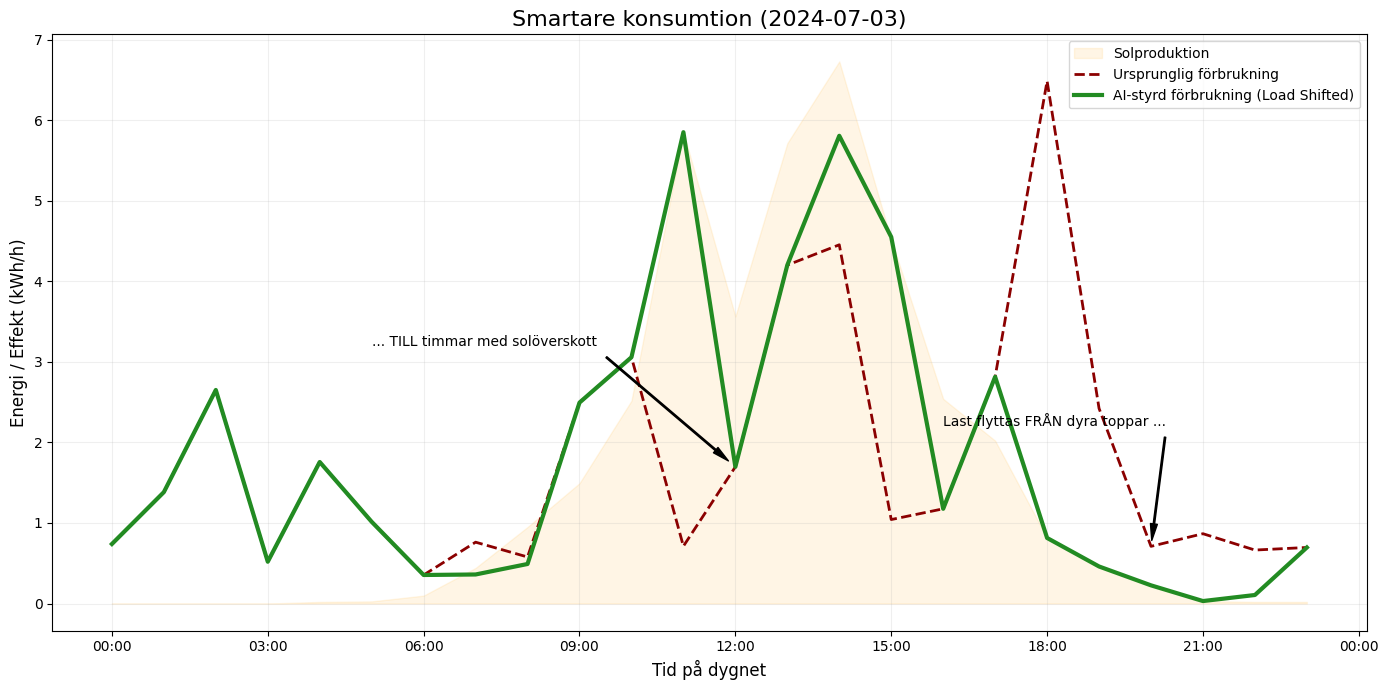

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. INSTÄLLNINGAR
# Ta en solig dag med både import (morgon/kväll) och export (mitt på dagen)
SAMPLE_DAY = '2024-07-03' 
SHIFT_LIMIT = 10.0 # kWh som AI:n tillåts flytta per dygn

# 2. FÖRBERED DATA FÖR EN SPECIFIK DAG
day_data = df.loc[SAMPLE_DAY].copy()

# Beräkna köppris för att identifiera toppar
day_data['buy_p'] = (day_data['price_total_ore'] / 100) * MOMS + TAX_FEES_KR

# Skapa kurvorna
original_load = day_data['total_house_load_kwh'].copy()
smart_load = original_load.copy()

# 3. AI-LOGIK: FLYTTA LASTEN (LOAD SHIFTING)
# Hitta timmar att flytta FRÅN (högst pris vid faktisk import)
can_reduce = day_data[day_data['grid_import_kwh'] > 0].sort_values('buy_p', ascending=False)
# Hitta timmar att flytta TILL (timmar med solöverskott)
can_increase = day_data[day_data['grid_export_kwh'] > 0].sort_values('grid_export_kwh', ascending=False)

# Beräkna hur mycket som kan flyttas för den aktuella dagen
to_shift = min(SHIFT_LIMIT, day_data['grid_import_kwh'].sum(), day_data['grid_export_kwh'].sum())

# Genomför flytten i datan
current_shift = to_shift
for idx, row in can_reduce.iterrows():
    take = min(current_shift, row['grid_import_kwh'])
    smart_load.loc[idx] -= take
    current_shift -= take
    if current_shift <= 0: break

current_shift = to_shift
for idx, row in can_increase.iterrows():
    use = min(current_shift, row['grid_export_kwh'])
    smart_load.loc[idx] += use
    current_shift -= use
    if current_shift <= 0: break

# 4. VISUALISERING
plt.figure(figsize=(14, 7))

# Solproduktionen som bakgrundsyta (kontext)
plt.fill_between(day_data.index, day_data['total_production_kwh'], 
                 color='orange', alpha=0.1, label='Solproduktion')

# Ursprunglig förbrukning
plt.plot(day_data.index, original_load, color='darkred', linewidth=2, 
         linestyle='--', label='Ursprunglig förbrukning')

# "Smart" AI-styrd förbrukning
plt.plot(day_data.index, smart_load, color='forestgreen', linewidth=3, 
         label='AI-styrd förbrukning (Load Shifted)')

# Formatering
plt.title(f'Smartare konsumtion ({SAMPLE_DAY})', fontsize=16)
plt.ylabel('Energi / Effekt (kWh/h)', fontsize=12)
plt.xlabel('Tid på dygnet', fontsize=12)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.grid(True, alpha=0.2)
plt.legend(loc='upper right', frameon=True)

# Lite förklaringar
plt.annotate('Last flyttas FRÅN dyra toppar ...', 
             xy=(day_data.index[20], original_load.iloc[20]), 
             xytext=(day_data.index[16], original_load.iloc[20]+1.5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.annotate('... TILL timmar med solöverskott', 
             xy=(day_data.index[12], smart_load.iloc[12]), 
             xytext=(day_data.index[5], smart_load.iloc[12]+1.5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.tight_layout()
plt.show()

Det här visar tydligt att ju 'smartare' man agerar genom Load Shifting, desto svårare blir det att räkna hem investeringen i ett batteri. Load Shifting har ju 100 % verkningsgrad och noll investeringskostnad, vilket 'stjäl' de mest lönsamma timmarna från batteriet. Ett batteri gör störst nytta med en 'dum' konsumtionskurva.

# AI-delen av projektet
För att uppfylla kunskapskraven kommer här ett AI-projekt baserat på mina data. Under arbetets gång har jag lärt mig mycket både om hur jag behöver strukturera koden och vilken skatt av information som är fritt tillänglig. online. 

In [ ]:
# Lite housekeeping - en del grejer är fragment från experiment, men de får stå kvar.

import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
from io import StringIO
from datetime import datetime, timedelta
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
import lightgbm as lgb
import optuna
from sklearn.model_selection import TimeSeriesSplit
optuna.logging.set_verbosity(optuna.logging.WARNING)
import calendar
import pulp
import os

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.3f}'.format)

# ── Konstanter ──
LAT, LON      = 56.67, 12.86          # Halmstad
STATION_ID    = 62410                  # Halmstad Flygplats
MASTER_CSV    = "Datainsamling/Del 3 - Data för projektet/master_energy_data_cleaned.csv"
TRAIN_CUTOFF  = "2025-07-01"          # Allt före = träning
STRANG_PARAM  = 117                    # Global irradians W/m²


In [3]:
# Ladda in data från CSV-filen
df_master = pd.read_csv(MASTER_CSV, parse_dates=['timestamp'])
df_master = df_master.sort_values('timestamp').set_index('timestamp')

print(f"Rader:   {len(df_master):,}")
print(f"Kolumner: {df_master.columns.tolist()}")
print(f"Period:  {df_master.index.min()} → {df_master.index.max()}")
df_master.head(3)

Rader:   21,961
Kolumner: ['hour', 'weekday', 'is_weekend', 'month', 'season', 'hour_sin', 'hour_cos', 'temp_c', 'irradiance_wm2', 'grid_import_kwh', 'grid_export_kwh', 'total_production_kwh', 'self_consumption_kwh', 'total_house_load_kwh', 'net_balance_kwh', 'price_total_ore']
Period:  2023-07-01 00:00:00 → 2025-12-31 23:00:00


,hour,weekday,is_weekend,month,season,hour_sin,hour_cos,temp_c,irradiance_wm2,grid_import_kwh,grid_export_kwh,total_production_kwh,self_consumption_kwh,total_house_load_kwh,net_balance_kwh,price_total_ore
timestamp,,,,,,,,,,,,,,,,
2023-07-01 00:00:00,0,5,1,7,summer,0.000,1.000,14.239,0.000,0.800,0.000,0.000,0.000,0.800,-0.800,0.000
2023-07-01 01:00:00,1,5,1,7,summer,0.259,0.966,14.938,0.000,2.400,0.000,0.000,0.000,2.400,-2.400,34.859
2023-07-01 02:00:00,2,5,1,7,summer,0.500,0.866,16.050,0.000,6.000,0.000,0.000,0.000,6.000,-6.000,34.481


In [4]:
def fetch_strang_hourly(lat, lon, param, date_from, date_to):
    """
    Jag hade inte koll på att även SMHI (via STRÅNG) har timvis data för solinstrålning 
    så jag kompletterar mina NASA-data med dessa.
    Returnerar en pd.Series med DateTime-index (Europe/Stockholm).
    Saknade värden (-999) ersätts med NaN.
    """
    from_str = date_from.strftime('%Y%m%d%H')   # format: YYYYMMDDHH
    to_str   = date_to.strftime('%Y%m%d%H')

    url = (
        f"https://opendata-download-metanalys.smhi.se/api/category/strang1g"
        f"/version/1/geotype/point/lon/{lon}/lat/{lat}"
        f"/parameter/{param}/data.txt"
        f"?from={from_str}&to={to_str}&interval=hourly"
    )
    print(f"Hämtar: {url}")
    r = requests.get(url, timeout=60)
    r.raise_for_status()

    # Parsa ASCII: år mån dag timme värde
    rows = []
    for line in r.text.strip().splitlines():
        parts = line.split()
        if len(parts) == 5:
            try:
                ts = pd.Timestamp(year=int(parts[0]), month=int(parts[1]),
                  day=int(parts[2]), hour=int(parts[3]),
                  tz='UTC'
                ).tz_convert('Europe/Stockholm').tz_localize(None)
                val = float(parts[4])
                rows.append((ts, val))
            except ValueError:
                continue

    s = pd.Series(
        {ts: v for ts, v in rows},
        name='strang_ghi_wm2'
    )
    s = s.replace(-999, np.nan)   # Saknade värden → NaN
    print(f"STRÅNG: {len(s):,} timmar | "
          f"Saknade: {s.isna().sum()} | "
          f"Max: {s.max():.0f} W/m²")
    return s

# Hämta hela perioden
date_from = datetime(2023, 7, 1, 0)
date_to   = datetime(2025, 12, 31, 23)
strang_series = fetch_strang_hourly(LAT, LON, STRANG_PARAM, date_from, date_to)
strang_series.head()


Hämtar: https://opendata-download-metanalys.smhi.se/api/category/strang1g/version/1/geotype/point/lon/12.86/lat/56.67/parameter/117/data.txt?from=2023070100&to=2025123123&interval=hourly
STRÅNG: 21,957 timmar | Saknade: 192 | Max: 871 W/m²


2023-07-01 02:00:00    0.000
2023-07-01 03:00:00    0.000
2023-07-01 04:00:00    0.000
2023-07-01 05:00:00    8.200
2023-07-01 06:00:00   54.300
Name: strang_ghi_wm2, dtype: float64

In [5]:
def fetch_metobs_temperature(station_id):
    """
    Hämtar timvis lufttemperatur (parameter 1) från SMHI metobs.
    Kombinerar corrected-archive + latest-months automatiskt.
    Returnerar en pd.Series med DateTime-index (UTC→Europe/Stockholm).
    """
    base = "https://opendata-download-metobs.smhi.se/api/version/1.0"
    frames = []

    for period in ['corrected-archive', 'latest-months']:
        url = f"{base}/parameter/1/station/{station_id}/period/{period}/data.csv"
        try:
            r = requests.get(url, timeout=30)
            r.raise_for_status()
            # SMHI CSV har metadata-rader i toppen — hoppa över dem
            lines = r.content.decode('utf-8-sig').splitlines()
            data_start = next(
                i for i, l in enumerate(lines)
                if l.startswith('Datum') or l.startswith('datum')
            )
            csv_text = '\n'.join(lines[data_start:])
            tmp = pd.read_csv(
                StringIO(csv_text),
                sep=';',
                usecols=[0, 1, 2],
                names=['datum', 'tid_utc', 'temp_obs'],
                skiprows=1,
                dtype={'temp_obs': str}
            )
            tmp['timestamp'] = pd.to_datetime(
                tmp['datum'] + ' ' + tmp['tid_utc'],
                utc=True,           # SMHI kör UTC av någon anledning
                errors='coerce'
            ).dt.tz_convert('Europe/Stockholm').dt.tz_localize(None)  # → lokal tid
            tmp['temp_obs'] = pd.to_numeric(tmp['temp_obs'], errors='coerce')
            frames.append(tmp[['timestamp', 'temp_obs']].dropna())
            print(f"  Period '{period}': {len(tmp)} rader")
        except Exception as e:
            print(f"  Period '{period}': hoppades över ({e})")

    df_obs = pd.concat(frames).drop_duplicates('timestamp')
    df_obs = df_obs.set_index('timestamp').sort_index()['temp_obs']
    df_obs.name = 'temp_obs_c'
    print(f"\nmetobs temp: {len(df_obs):,} timmar | "
          f"Period: {df_obs.index.min().date()} → {df_obs.index.max().date()}")
    return df_obs

temp_obs = fetch_metobs_temperature(STATION_ID)
temp_obs.head()


  Period 'corrected-archive': 255944 rader
  Period 'latest-months': 3132 rader

metobs temp: 258,466 timmar | Period: 1945-02-06 → 2026-04-16


timestamp
1945-02-06 08:00:00   0.400
1945-02-06 14:00:00   1.000
1945-02-07 08:00:00   1.200
1945-02-07 14:00:00   1.800
1945-02-08 08:00:00   1.800
Name: temp_obs_c, dtype: float64

In [7]:
# Slå ihop alla datakällor
df = df_master.copy()
df['strang_ghi']  = strang_series
df['temp_obs']    = temp_obs

# Interpolera korta luckor i STRÅNG (max 2h)
df['strang_ghi'] = df['strang_ghi'].interpolate(method='time', limit=2)

# ── Kalenderfeatures ──
df['hour']       = df.index.hour
df['month']      = df.index.month
df['weekday']    = df.index.dayofweek
df['day_of_year']= df.index.dayofyear

# Solhorisontell strålning minskar mot morgon/kväll → modelleras med sin-kurva
df['solar_angle'] = np.sin(
    np.pi * (df['hour'] - 6) / 14          # 0 vid 6:00, max vid 13:00, 0 vid 20:00
).clip(lower=0)

# Daglig aggregat-features (för prognos dagen efter)
daily = df.resample('D').agg(
    production     = ('total_production_kwh', 'sum'),
    strang_mean    = ('strang_ghi', 'mean'),
    strang_max     = ('strang_ghi', 'max'),
    temp_max       = ('temp_obs', 'max'),
    temp_mean      = ('temp_obs', 'mean'),
    house_load_sum = ('total_house_load_kwh', 'sum'),
    month          = ('month', 'first'),
    weekday        = ('weekday', 'first'),
    day_of_year    = ('day_of_year', 'first'),
).dropna(subset=['production', 'strang_mean'])

# Laggade features (ingen data leakage!)
for lag in [1, 2, 7]:
    daily[f'prod_lag{lag}']   = daily['production'].shift(lag)
    daily[f'strang_lag{lag}'] = daily['strang_mean'].shift(lag)

daily['prod_roll7']   = daily['production'].shift(1).rolling(7).mean()
daily['prod_roll14']  = daily['production'].shift(1).rolling(14).mean()
daily['strang_roll7'] = daily['strang_mean'].shift(1).rolling(7).mean()

# Årstidscykel 
daily['season_sin'] = np.sin(2 * np.pi * daily['day_of_year'] / 365.25)
daily['season_cos'] = np.cos(2 * np.pi * daily['day_of_year'] / 365.25)

# Target = nästa dags produktion
daily['target'] = daily['production'].shift(-1)
daily = daily.dropna()

print(f"Dataunderlag klart: {len(daily)} dagar")
print(f"Träning (< {TRAIN_CUTOFF}): {(daily.index < TRAIN_CUTOFF).sum()} dagar")
print(f"Test   (≥ {TRAIN_CUTOFF}): {(daily.index >= TRAIN_CUTOFF).sum()} dagar")
daily.head(3)


Dataunderlag klart: 892 dagar
Träning (< 2025-07-01): 710 dagar
Test   (≥ 2025-07-01): 182 dagar


,production,strang_mean,strang_max,temp_max,temp_mean,house_load_sum,month,weekday,day_of_year,prod_lag1,...,prod_lag2,strang_lag2,prod_lag7,strang_lag7,prod_roll7,prod_roll14,strang_roll7,season_sin,season_cos,target
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-07-15,24.525,205.487,674.700,26.100,19.754,47.425,7,5,196,53.221,...,52.053,304.775,56.102,331.250,40.874,36.632,260.129,-0.228,-0.974,40.077
2023-07-16,40.077,250.362,791.600,21.800,18.954,51.577,7,6,197,24.525,...,53.221,314.988,55.834,326.050,36.363,37.906,242.163,-0.245,-0.970,45.520
2023-07-17,45.520,245.112,767.800,19.400,17.062,39.520,7,0,198,40.077,...,24.525,205.487,13.103,150.908,34.112,37.389,231.351,-0.261,-0.965,37.902


In [8]:
FEATURES = [
    'strang_lag1', 'strang_lag2', 'strang_lag7', 'strang_roll7',
    'strang_max',
    'temp_max', 'temp_mean',
    'prod_lag1', 'prod_lag2', 'prod_lag7',
    'prod_roll7', 'prod_roll14',
    'month', 'weekday', 'season_sin', 'season_cos',
]

mask_train = daily.index < TRAIN_CUTOFF
mask_test  = daily.index >= TRAIN_CUTOFF

X_train = daily.loc[mask_train, FEATURES]
y_train = daily.loc[mask_train, 'target']
X_test  = daily.loc[mask_test,  FEATURES]
y_test  = daily.loc[mask_test,  'target']

model = HistGradientBoostingRegressor(
    max_iter             = 1000,
    learning_rate        = 0.02,
    max_depth            = 4,
    min_samples_leaf     = 5,
    l2_regularization    = 0.5,
    random_state         = 42,
    early_stopping       = True,
    validation_fraction  = 0.15,
    n_iter_no_change     = 50,
)
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

def metrics(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{label:10}  MAE={mae:.2f} kWh  RMSE={rmse:.2f} kWh  R²={r2:.4f}")
    return {'mae': mae, 'rmse': rmse, 'r2': r2}

print(f"Antal träningsdagar: {len(X_train)}")
print(f"Tidiga stopp vid iteration: {model.n_iter_}")
print()
res_train = metrics(y_train, y_pred_train, "TRÄNING")
res_test  = metrics(y_test,  y_pred_test,  "TEST")

Antal träningsdagar: 710
Tidiga stopp vid iteration: 186

TRÄNING     MAE=7.61 kWh  RMSE=9.53 kWh  R²=0.7390
TEST        MAE=8.92 kWh  RMSE=11.01 kWh  R²=0.6162


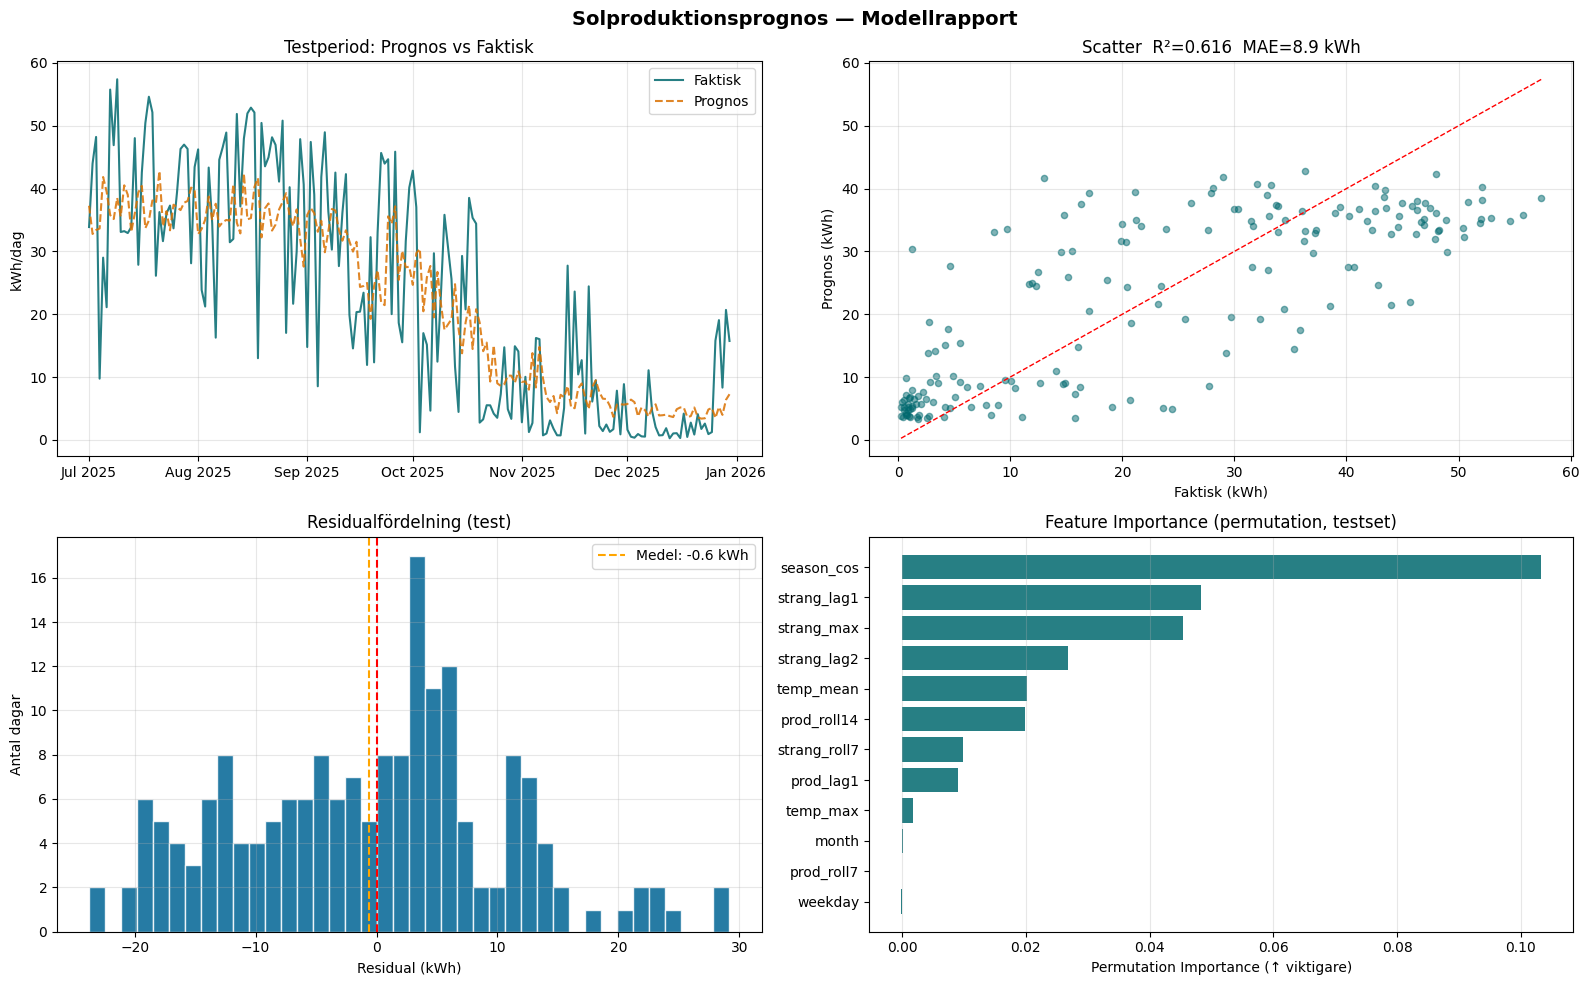

Rapport sparad: model_report.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Solproduktionsprognos — Modellrapport', fontsize=14, fontweight='bold')

# Panel 1: Prognos vs faktisk (testperiod)
ax = axes[0, 0]
ax.plot(daily.loc[mask_test].index, y_test.values,
        label='Faktisk', color='#01696f', linewidth=1.5, alpha=0.85)
ax.plot(daily.loc[mask_test].index, y_pred_test,
        label='Prognos', color='#da7101', linewidth=1.5, alpha=0.85, linestyle='--')
ax.set_title('Testperiod: Prognos vs Faktisk')
ax.set_ylabel('kWh/dag')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend()
ax.grid(alpha=0.3)

# Panel 2: Scatter prognos vs faktisk
ax = axes[0, 1]
ax.scatter(y_test, y_pred_test, alpha=0.5, color='#01696f', s=20)
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
ax.plot(lims, lims, 'r--', linewidth=1)
ax.set_xlabel('Faktisk (kWh)'); ax.set_ylabel('Prognos (kWh)')
ax.set_title(f"Scatter  R²={res_test['r2']:.3f}  MAE={res_test['mae']:.1f} kWh")
ax.grid(alpha=0.3)

# Panel 3: Residualfördelning
ax = axes[1, 0]
residuals = y_pred_test - y_test.values
ax.hist(residuals, bins=40, color='#006494', edgecolor='white', alpha=0.85)
ax.axvline(0, color='red', linestyle='--')
ax.axvline(residuals.mean(), color='orange', linestyle='--',
           label=f'Medel: {residuals.mean():.1f} kWh')
ax.set_xlabel('Residual (kWh)'); ax.set_ylabel('Antal dagar')
ax.set_title('Residualfördelning (test)')
ax.legend(); ax.grid(alpha=0.3)

# Panel 4: Feature importance
ax = axes[1, 1]
imp_result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
imp_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': imp_result.importances_mean
}).sort_values('importance', ascending=True).tail(12)
bars = ax.barh(imp_df['feature'], imp_df['importance'], color='#01696f', alpha=0.85)
ax.set_xlabel('Permutation Importance (↑ viktigare)')
ax.set_title('Feature Importance (permutation, testset)')
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('model_report.png', dpi=150, bbox_inches='tight')
plt.show()
print("Rapport sparad: model_report.png")


Några kommentarer:

1. I diagrammet Prognos vs Faktisk (övre vänster) ser vi hur prognosen inte är så dålig på att pricka trenden, men missar topparna och dalarna som är så viktiga för den här funktionen. Detta beror på att modellen saknar framåtblickande väderfeatures. Det är så det blir i en trädbaserad modell utan väderprognosinput. Detta får vi titta på i nästa steg.

2. Scatterdiagrammet har två tydliga mönster - på samma tema. Den underskattar höga värden och chansar aldrig på de riktigt soliga dagarna. 

3. Residualfördelningen (nedre vänster) visar att modellen är svagt pessimistisk och det får jag aceptera. Residualer upp mot +30 kWh är missade soliga sommardagar som modellen underskattar.

4. Listan på features som är viktiga för modellen visar föga överraskande att season_cos är viktigast medan veckodag är minst viktigt. 

Jag gjorde lite research och det visar sig att jag slarvat när jag hämtat NASA-data. Jag behöver komplettera med ALLSKY_KT (klarhetsindex).  låter delarna ovan stå kvar för att visa hur arbetsgången varit. 


In [10]:
# SMHI STRÅNG + läs NASA ALLSKY_KT från fil

# Hårdkodad period
date_from = datetime(2023, 7, 1, 0)
date_to   = datetime(2025, 12, 31, 23)

KT_CSV = r"Datainsamling/Del 3 - Data för projektet/nasa_allsky_kt.csv"

# STRÅNG

def fetch_strang_hourly(lat, lon, param, date_from, date_to):
    from_str = date_from.strftime('%Y%m%d%H')
    to_str   = date_to.strftime('%Y%m%d%H')
    url = (
        f"https://opendata-download-metanalys.smhi.se/api/category/strang1g"
        f"/version/1/geotype/point/lon/{lon}/lat/{lat}"
        f"/parameter/{param}/data.txt"
        f"?from={from_str}&to={to_str}&interval=hourly"
    )
    print("Hämtar STRÅNG...")
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    rows = []
    for line in r.text.strip().splitlines():
        parts = line.split()
        if len(parts) == 5:
            try:
                ts = pd.Timestamp(
                    year=int(parts[0]), month=int(parts[1]),
                    day=int(parts[2]),  hour=int(parts[3]),
                    tz='UTC'
                ).tz_convert('Europe/Stockholm').tz_localize(None)
                rows.append((ts, float(parts[4])))
            except ValueError:
                continue
    s = pd.Series({ts: v for ts, v in rows}, name='strang_ghi_wm2')
    s = s.replace(-999, np.nan)
    print(f"STRÅNG: {len(s):,} timmar | Saknade: {s.isna().sum()} | Max: {s.max():.0f} W/m²")
    return s

strang_series = fetch_strang_hourly(LAT, LON, STRANG_PARAM, date_from, date_to)

# NASA ALLSKY_KT från fil

kt_series = pd.read_csv(
    KT_CSV,
    index_col='timestamp',
    parse_dates=['timestamp']
)['allsky_kt']

kt_series = kt_series.groupby(kt_series.index).mean()

df_master['allsky_kt'] = df_master.index.astype('datetime64[ns]').map(kt_series)

print(f"ALLSKY_KT: {len(kt_series):,} timmar | Period: {kt_series.index.min().date()} → {kt_series.index.max().date()}")
print(f"Matchade rader:  {df_master['allsky_kt'].notna().sum():,} av {len(df_master):,}")
print(f"Saknade:         {df_master['allsky_kt'].isna().sum()}")

Hämtar STRÅNG...
STRÅNG: 21,957 timmar | Saknade: 192 | Max: 871 W/m²
ALLSKY_KT: 21,960 timmar | Period: 2023-07-01 → 2025-12-31
Matchade rader:  11,115 av 21,961
Saknade:         10846


In [11]:
# SMHI metobs: timvis lufttemperatur för flygplatsen som bara är några km bort

METOBS_CSV = r"Datainsamling/Del 3 - Data för projektet/smhi_metobs.csv"

def fetch_metobs_temperature(station_id):
    base   = "https://opendata-download-metobs.smhi.se/api/version/1.0"
    frames = []

    for period in ['corrected-archive', 'latest-months']:
        url = f"{base}/parameter/1/station/{station_id}/period/{period}/data.csv"
        try:
            r = requests.get(url, timeout=30)
            r.raise_for_status()
            lines      = r.content.decode('utf-8-sig').splitlines()
            data_start = next(
                i for i, l in enumerate(lines)
                if l.startswith('Datum') or l.startswith('datum')
            )
            csv_text = '\n'.join(lines[data_start:])
            tmp = pd.read_csv(
                StringIO(csv_text),
                sep=';',
                usecols=[0, 1, 2],
                names=['datum', 'tid_utc', 'temp_obs'],
                skiprows=1,
                dtype={'temp_obs': str}
            )
            tmp['timestamp'] = pd.to_datetime(
                tmp['datum'] + ' ' + tmp['tid_utc'],
                utc=True,
                errors='coerce'
            ).dt.tz_convert('Europe/Stockholm').dt.tz_localize(None)
            tmp['temp_obs'] = pd.to_numeric(tmp['temp_obs'], errors='coerce')
            frames.append(tmp[['timestamp', 'temp_obs']].dropna())
            print(f"  Period '{period}': {len(tmp)} rader")
        except Exception as e:
            print(f"  Period '{period}': hoppades över ({e})")

    df_obs = pd.concat(frames).drop_duplicates('timestamp')
    df_obs = df_obs.set_index('timestamp').sort_index()['temp_obs']
    df_obs.name = 'temp_obs_c'

    # Spara som CSV
    df_obs.to_csv(METOBS_CSV, index=True, index_label='timestamp')

    print(f"\nMetobs temp: {len(df_obs):,} timmar | "
          f"Period: {df_obs.index.min().date()} → {df_obs.index.max().date()} | "
          f"Sparad: {METOBS_CSV}")
    return df_obs


temp_obs = fetch_metobs_temperature(STATION_ID)
temp_obs.head()

  Period 'corrected-archive': 255944 rader
  Period 'latest-months': 3132 rader

Metobs temp: 258,466 timmar | Period: 1945-02-06 → 2026-04-16 | Sparad: Datainsamling/Del 3 - Data för projektet/smhi_metobs.csv


timestamp
1945-02-06 08:00:00   0.400
1945-02-06 14:00:00   1.000
1945-02-07 08:00:00   1.200
1945-02-07 14:00:00   1.800
1945-02-08 08:00:00   1.800
Name: temp_obs_c, dtype: float64

In [12]:
# Slå ihop datakällor och bygg timvisa features

df = df_master.copy()
df = df.rename(columns={
    'total_production_kwh': 'totalproductionkwh',
    'allsky_kt':            'allskykt',
})

# Interpolera korta luckor i STRÅNG max 2h
df['strangghiwm2'] = strang_series   # ← lägg till denna rad
df['strangghiwm2'] = df['strangghiwm2'].interpolate(method='time', limit=2)

# Lägg till temp_obs
df['tempobs'] = temp_obs   

# Kalenderfeatures
df['hour'] = df.index.hour
df['month'] = df.index.month
df['weekday'] = df.index.dayofweek
df['dayofyear'] = df.index.dayofyear

# Solhöjdsapproximation
df['solarangle'] = np.clip(np.sin(np.pi * (df['hour'] - 6) / 14), 0, None)

# Timvisa lag-features
for lag_h in [24, 48, 168]:
    df[f'prod_lag{lag_h}h'] = df['totalproductionkwh'].shift(lag_h)
    df[f'strang_lag{lag_h}h'] = df['strangghiwm2'].shift(lag_h)
    df[f'kt_lag{lag_h}h'] = df['allskykt'].shift(lag_h)

# Rullande historik på timnivå
df['prod_roll7d'] = df['totalproductionkwh'].shift(24).rolling(7 * 24, min_periods=24).mean()
df['prod_roll14d'] = df['totalproductionkwh'].shift(24).rolling(14 * 24, min_periods=24).mean()
df['strang_roll7d'] = df['strangghiwm2'].shift(24).rolling(7 * 24, min_periods=24).mean()

# Årstidscykel
df['season_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 365.25)
df['season_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 365.25)

# Timvis target
df['target_log'] = np.log1p(df['totalproductionkwh'])

# Träna bara på timmar där solen faktiskt kan bidra
dfh = df[df['solarangle'] > 0].copy()

required_cols = [
    'solarangle',
    'strangghiwm2',
    'allskykt',
    'tempobs',
    'hour',
    'month',
    'season_sin',
    'season_cos',
    'prod_lag24h',
    'prod_lag48h',
    'prod_lag168h',
    'strang_lag24h',
    'strang_lag48h',
    'strang_lag168h',
    'kt_lag24h',
    'kt_lag48h',
    'kt_lag168h',
    'prod_roll7d',
    'prod_roll14d',
    'strang_roll7d',
    'target_log',
]

dfh = dfh.dropna(subset=required_cols)

# Behåll daily för enkel dagssummering och utskrift
daily = df.resample('D').agg(
    production=('totalproductionkwh', 'sum'),
    strang_mean=('strangghiwm2', 'mean'),
    kt_mean=('allskykt', 'mean'),
).dropna()

print(f"Timvis dataset klart: {len(dfh)} rader")
print(f"Period: {dfh.index.min()} → {dfh.index.max()}")
print(f"Träning: {(dfh.index < pd.Timestamp(TRAIN_CUTOFF)).sum()} timmar")
print(f"Test:    {(dfh.index >= pd.Timestamp(TRAIN_CUTOFF)).sum()} timmar")

dfh.head(3)

Timvis dataset klart: 9206 rader
Period: 2023-07-08 07:00:00 → 2025-12-30 14:00:00
Träning: 7362 timmar
Test:    1844 timmar


,hour,weekday,is_weekend,month,season,hour_sin,hour_cos,temp_c,irradiance_wm2,grid_import_kwh,...,kt_lag48h,prod_lag168h,strang_lag168h,kt_lag168h,prod_roll7d,prod_roll14d,strang_roll7d,season_sin,season_cos,target_log
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-07-08 07:00:00,7,5,1,7,summer,0.966,-0.259,24.500,286.520,0.100,...,0.210,0.253,90.200,0.270,1.172,1.172,194.749,-0.109,-0.994,0.730
2023-07-08 08:00:00,8,5,1,7,summer,0.866,-0.500,25.950,428.580,0.000,...,0.180,0.752,133.200,0.260,1.181,1.181,195.822,-0.109,-0.994,1.345
2023-07-08 09:00:00,9,5,1,7,summer,0.707,-0.707,27.062,566.450,0.000,...,0.170,0.656,202.800,0.280,1.203,1.203,195.684,-0.109,-0.994,1.715


In [13]:
# Träna timvis modell

FEATURES = [
    'solarangle',
    'strangghiwm2',
    'allskykt',
    'tempobs',
    'hour',
    'month',
    'season_sin',
    'season_cos',
    'prod_lag24h',
    'prod_lag48h',
    'prod_lag168h',
    'strang_lag24h',
    'strang_lag48h',
    'strang_lag168h',
    'kt_lag24h',
    'kt_lag48h',
    'kt_lag168h',
    'prod_roll7d',
    'prod_roll14d',
    'strang_roll7d',
]

mask_train = dfh.index < pd.Timestamp(TRAIN_CUTOFF)
mask_test = dfh.index >= pd.Timestamp(TRAIN_CUTOFF)

X_train = dfh.loc[mask_train, FEATURES]
y_train = dfh.loc[mask_train, 'target_log']

X_test = dfh.loc[mask_test, FEATURES]
y_test = dfh.loc[mask_test, 'target_log']

model = HistGradientBoostingRegressor(
    max_iter=1000,
    learning_rate=0.02,
    max_depth=5,
    min_samples_leaf=10,
    l2_regularization=0.3,
    loss='squared_error',
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=50,
    random_state=42,
)

model.fit(X_train, y_train)
y_pred_test = np.clip(np.expm1(model.predict(X_test)), 0, None)
y_pred_train = np.clip(np.expm1(model.predict(X_train)), 0, None)

def metrics(ytrue_log, ypred_log, label):
    ytrue = np.expm1(ytrue_log)
    ypred = np.clip(np.expm1(ypred_log), 0, None)
    mae = mean_absolute_error(ytrue, ypred)
    rmse = np.sqrt(mean_squared_error(ytrue, ypred))
    r2 = r2_score(ytrue, ypred)
    print(f"{label:<10} MAE={mae:.2f} kWh  RMSE={rmse:.2f} kWh  R²={r2:.4f}")
    return {'mae': mae, 'rmse': rmse, 'r2': r2}

print(f"Antal träningsrader: {len(X_train)}")
print(f"Tidiga stopp vid iteration: {model.n_iter_}")
print()

res_train = metrics(y_train, model.predict(X_train), "TRÄNING")
res_test = metrics(y_test, model.predict(X_test), "TEST")

Antal träningsrader: 7362
Tidiga stopp vid iteration: 1000

TRÄNING    MAE=0.35 kWh  RMSE=0.57 kWh  R²=0.9373
TEST       MAE=0.49 kWh  RMSE=0.80 kWh  R²=0.8662


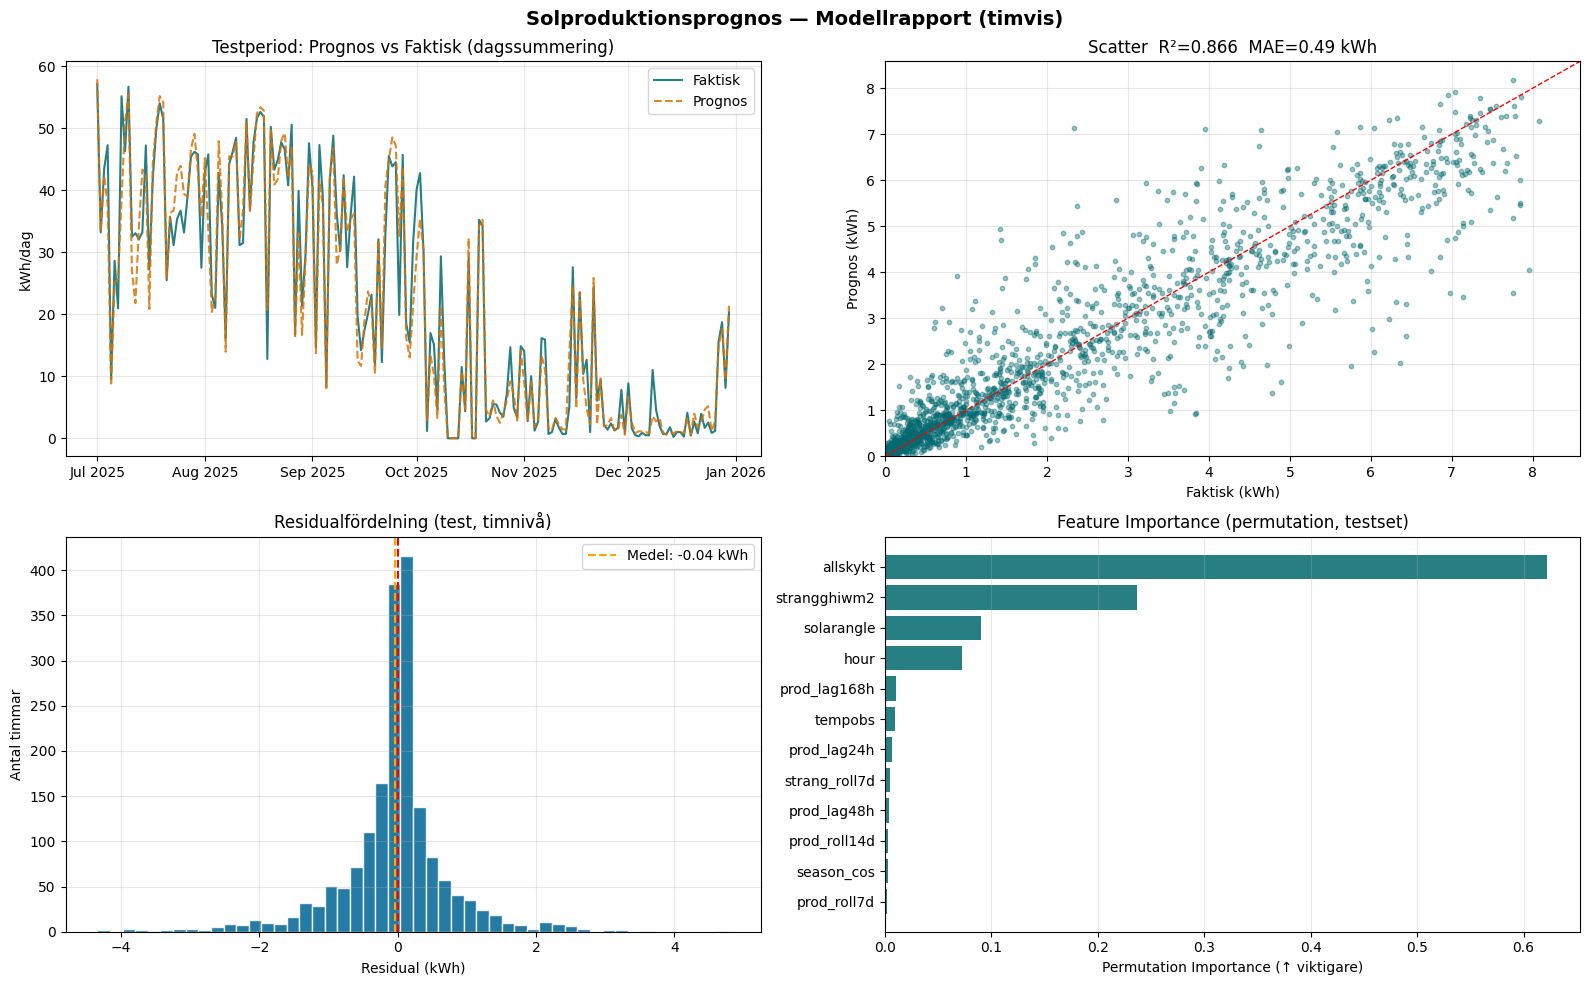

Rapport sparad: model_report.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Solproduktionsprognos — Modellrapport (timvis)', fontsize=14, fontweight='bold')

# Konvertera y_test från log-rymd → kWh
y_test_kwh  = np.expm1(y_test)                                              # Series med korrekt index
y_pred_test = np.clip(np.expm1(model.predict(X_test)), 0, None)             # ndarray i kWh
y_pred_series = pd.Series(y_pred_test, index=X_test.index, name='predicted_kwh')

# Summera timvisa värden till dag för en läsbar linjegraf
actual_daily  = y_test_kwh.resample('D').sum()
pred_daily    = y_pred_series.resample('D').sum()

# ── Panel 1: Prognos vs faktisk (testperiod, daglig summering) ──
ax = axes[0, 0]
ax.plot(actual_daily.index, actual_daily.values,
        label='Faktisk', color='#01696f', linewidth=1.5, alpha=0.85)
ax.plot(pred_daily.index, pred_daily.values,
        label='Prognos', color='#da7101', linewidth=1.5, alpha=0.85, linestyle='--')
ax.set_title('Testperiod: Prognos vs Faktisk (dagssummering)')
ax.set_ylabel('kWh/dag')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend()
ax.grid(alpha=0.3)

# ── Panel 2: Scatter prognos vs faktisk (timnivå) ──
ax = axes[0, 1]
ax.scatter(y_test_kwh.values, y_pred_test, alpha=0.4, color='#01696f', s=10)
lims = [0, max(y_test_kwh.max(), y_pred_test.max()) * 1.05]
ax.plot(lims, lims, 'r--', linewidth=1)
ax.set_xlabel('Faktisk (kWh)')
ax.set_ylabel('Prognos (kWh)')
ax.set_title(f"Scatter  R²={res_test['r2']:.3f}  MAE={res_test['mae']:.2f} kWh")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.grid(alpha=0.3)

# ── Panel 3: Residualfördelning (kWh) ──
ax = axes[1, 0]
residuals = y_pred_test - y_test_kwh.values
ax.hist(residuals, bins=50, color='#006494', edgecolor='white', alpha=0.85)
ax.axvline(0, color='red', linestyle='--')
ax.axvline(residuals.mean(), color='orange', linestyle='--',
           label=f'Medel: {residuals.mean():.2f} kWh')
ax.set_xlabel('Residual (kWh)')
ax.set_ylabel('Antal timmar')
ax.set_title('Residualfördelning (test, timnivå)')
ax.legend()
ax.grid(alpha=0.3)

# ── Panel 4: Feature importance (log-rymd, korrekt för modellen) ──
ax = axes[1, 1]
imp_result = permutation_importance(model, X_test, y_test,   # ← log-rymd är rätt här
                                    n_repeats=10, random_state=42)
imp_df = pd.DataFrame({
    'feature':    FEATURES,
    'importance': imp_result.importances_mean
}).sort_values('importance', ascending=True).tail(12)

ax.barh(imp_df['feature'], imp_df['importance'], color='#01696f', alpha=0.85)
ax.set_xlabel('Permutation Importance (↑ viktigare)')
ax.set_title('Feature Importance (permutation, testset)')
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('model_report.png', dpi=150, bbox_inches='tight')
plt.show()
print("Rapport sparad: model_report.png")

Äntligen en bra modell - nu kör vi nästa steg. 

In [16]:
def fetch_smhi_forecast(lat, lon):
    """
    Hämtar SMHI:s 10-dygns timprognos via snow1g/version/1 (ersätter pmp3g 2026-03-31).
    data-fältet är ett dict: {"air_temperature": 12.3, "tcc_mean": 6, ...}
    Det handlar inte om snö utan är SNOW (Swedish National Operational Weather forecast),
    en sammanställning av prognoser som uppdateras var 15:e minut.
    """
    url = (
        f"https://opendata-download-metfcst.smhi.se/api/category/snow1g"
        f"/version/1/geotype/point/lon/{lon}/lat/{lat}/data.json"
    )
    r = requests.get(url, timeout=15)
    r.raise_for_status()

    rows = []
    for step in r.json()['timeSeries']:
        ts = (pd.Timestamp(step['time'])          # ← 'time' är korrekt
              .tz_convert('Europe/Stockholm')
              .tz_localize(None))
        d = step['data']   # ← dict direkt, stämmer
        rows.append({
            'timestamp':         ts,
            'temp_c':            d.get('air_temperature'),
            'humidity_pct':      d.get('relative_humidity'),
            'cloud_total_octas': d.get('cloud_area_fraction'),          # ← nytt namn
            'cloud_low_octas':   d.get('low_type_cloud_area_fraction'), # ← nytt namn
            'weather_symbol':    d.get('symbol_code'),                  # ← nytt namn
        })

    fcst = pd.DataFrame(rows).set_index('timestamp')
    fcst['cloud_total_pct'] = fcst['cloud_total_octas'] * (100 / 8)
    fcst['cloud_low_pct']   = fcst['cloud_low_octas']   * (100 / 8)

    print(f"snow1g: {len(fcst)} timmar | "
          f"{fcst.index.min().date()} → {fcst.index.max().date()}")
    return fcst

def lookup_or_fallback(frame, col, ts, fallback):
    try:
        val = frame.loc[ts, col]
        return fallback if pd.isna(val) else val
    except KeyError:
        return fallback


def build_tomorrow_hourly_features(df_hist, fcst_df):
    tomorrow  = (pd.Timestamp.now() + pd.Timedelta(days=1)).date()
    tmrw_fcst = fcst_df[fcst_df.index.date == tomorrow].copy()

    if tmrw_fcst.empty:
        available = sorted(set(fcst_df.index.date))
        raise ValueError(f"Ingen prognos för {tomorrow}.\nTillgängliga datum: {available}")

    hour_arr    = tmrw_fcst.index.hour.to_numpy()
    solar_angle = np.clip(np.sin(np.pi * (hour_arr - 6) / 14), 0, None)
    month          = tomorrow.month
    clear_sky_peak = 200 + 600 * np.sin(np.pi * (month - 1) / 11)
    cloud_factor_h = 1 - tmrw_fcst['cloud_total_pct'].fillna(100).to_numpy() / 100
    strang_h       = clear_sky_peak * solar_angle * cloud_factor_h
    kt_h           = np.where(solar_angle > 0, cloud_factor_h, 0.0)

    hist_end      = df_hist.index.max()
    prod_roll7d   = df_hist.loc[df_hist.index <= hist_end, 'totalproductionkwh'].tail(7*24).mean()
    prod_roll14d  = df_hist.loc[df_hist.index <= hist_end, 'totalproductionkwh'].tail(14*24).mean()
    strang_roll7d = df_hist.loc[df_hist.index <= hist_end, 'strangghiwm2'].tail(7*24).mean()

    rows = []
    for i, ts in enumerate(tmrw_fcst.index):
        if solar_angle[i] <= 0:
            continue
        rows.append({
            'timestamp':      ts,
            'solarangle':     solar_angle[i],
            'strangghiwm2':   strang_h[i],
            'allskykt':       kt_h[i],
            'tempobs':        tmrw_fcst['temp_c'].iloc[i],
            'hour':           ts.hour,
            'month':          ts.month,
            'season_sin':     np.sin(2 * np.pi * ts.timetuple().tm_yday / 365.25),
            'season_cos':     np.cos(2 * np.pi * ts.timetuple().tm_yday / 365.25),
            'prod_lag24h':    lookup_or_fallback(df_hist, 'totalproductionkwh', ts - pd.Timedelta(hours=24),  prod_roll7d),
            'prod_lag48h':    lookup_or_fallback(df_hist, 'totalproductionkwh', ts - pd.Timedelta(hours=48),  prod_roll7d),
            'prod_lag168h':   lookup_or_fallback(df_hist, 'totalproductionkwh', ts - pd.Timedelta(hours=168), prod_roll7d),
            'strang_lag24h':  lookup_or_fallback(df_hist, 'strangghiwm2',       ts - pd.Timedelta(hours=24),  strang_roll7d),
            'strang_lag48h':  lookup_or_fallback(df_hist, 'strangghiwm2',       ts - pd.Timedelta(hours=48),  strang_roll7d),
            'strang_lag168h': lookup_or_fallback(df_hist, 'strangghiwm2',       ts - pd.Timedelta(hours=168), strang_roll7d),
            'kt_lag24h':      lookup_or_fallback(df_hist, 'allskykt', ts - pd.Timedelta(hours=24),  0.0),
            'kt_lag48h':      lookup_or_fallback(df_hist, 'allskykt', ts - pd.Timedelta(hours=48),  0.0),
            'kt_lag168h':     lookup_or_fallback(df_hist, 'allskykt', ts - pd.Timedelta(hours=168), 0.0),
            'prod_roll7d':    prod_roll7d,
            'prod_roll14d':   prod_roll14d,
            'strang_roll7d':  strang_roll7d,
        })

    X_pred = pd.DataFrame(rows).set_index('timestamp')
    return X_pred, tomorrow


fcst_df = fetch_smhi_forecast(LAT, LON)

X_pred_hourly, tomorrow_date = build_tomorrow_hourly_features(df, fcst_df)

hourly_pred_tomorrow = X_pred_hourly.copy()
hourly_pred_tomorrow['predicted_kwh'] = np.clip(
    np.expm1(model.predict(hourly_pred_tomorrow[FEATURES])),
    0, None
)

predicted_kwh = hourly_pred_tomorrow['predicted_kwh'].sum()

print(f"\nPrognos för: {tomorrow_date}")
print(f"🌤 Molntäckning (dygnssnitt): "
      f"{fcst_df[fcst_df.index.date == tomorrow_date]['cloud_total_pct'].mean():.0f}%")
print(f"🌡 Temperatur max: "
      f"{fcst_df[fcst_df.index.date == tomorrow_date]['temp_c'].max():.1f}°C")
print(f"⚡ Prognos produktion: {predicted_kwh:.1f} kWh")

snow1g: 74 timmar | 2026-04-16 → 2026-04-27

Prognos för: 2026-04-17
🌤 Molntäckning (dygnssnitt): 51%
🌡 Temperatur max: 15.4°C
⚡ Prognos produktion: 46.2 kWh



📅 Rekommendation för 2026-04-17 — day-ahead SE4

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  REKOMMENDATION TIMME FÖR TIMME  —  2026-04-17  —  SE4
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Tim      Sol    Öre  Batteri                       Elbil                           Vitvaror
  ─────  ─────  ─────  ────────────────────────────  ──────────────────────────────  ────────────────────────────
  00:00   0.00  135.8  🔋 Ladda ur (högt pris)        😴 Väntar på billigaste blocket  🌙 Utanför tillåten tid (06–21)
  01:00   0.00  114.7  ⏸️  Neutral — håll SOC        😴 Väntar på billigaste blocket  🌙 Utanför tillåten tid (06–21)
  02:00   0.00  110.1  ⏸️  Neutral — håll SOC        🔌 Ladda (110 öre)               🌙 Utanför tillåten tid (06–21)
  03:00   0.00  100.2  ⏸️  Neutral — håll SOC        🔌 Ladda (100 öre)               🌙 Utanför tillåten tid (06–21)
  04:00   0.00   98.2  ⏸️  Neu

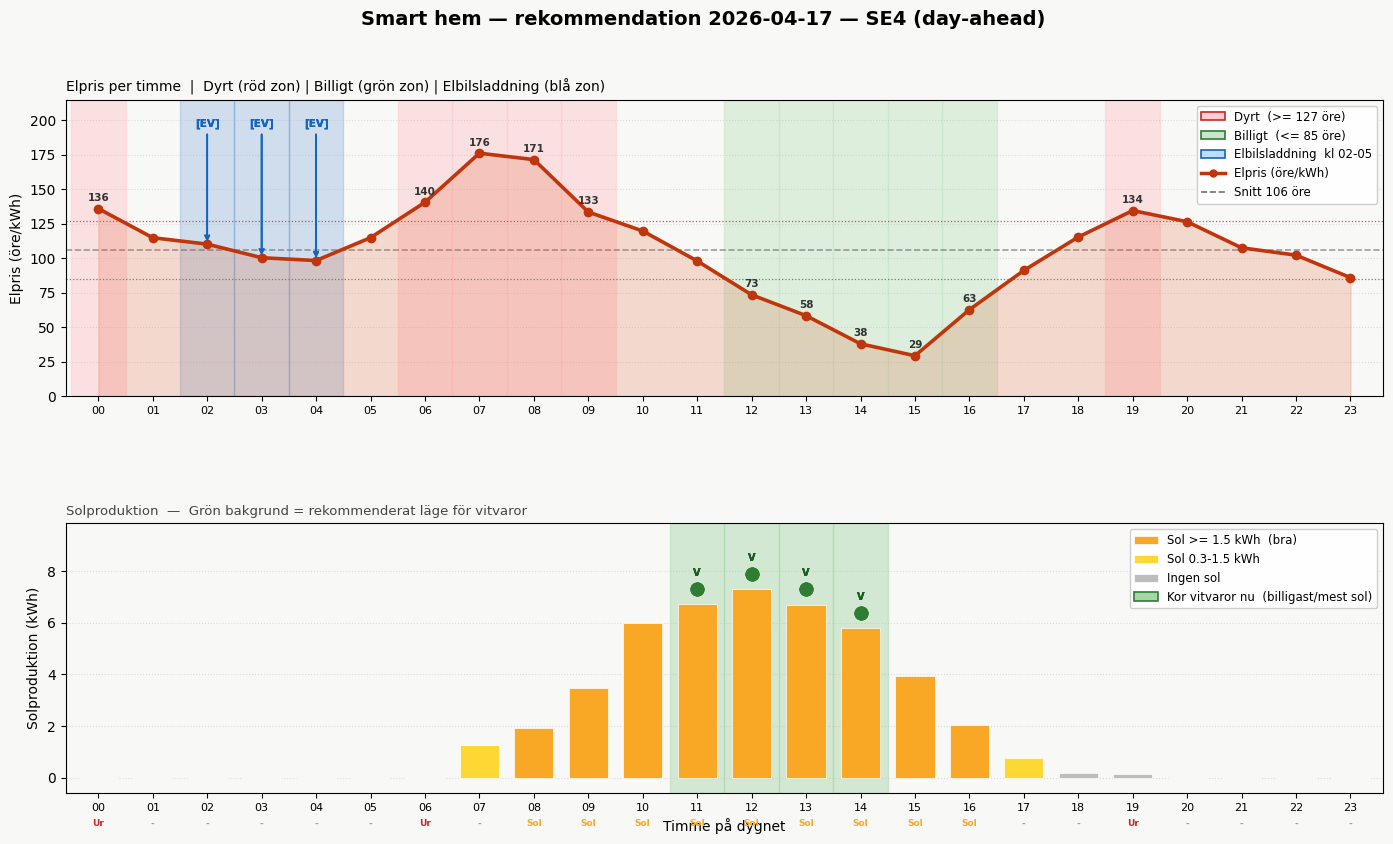

Sparad: steg1_kvallsrapport.png


In [17]:
# Solprognos + Day-ahead-priser SE4

import datetime as dt

now      = pd.Timestamp.now()
after_14 = now.hour >= 14

# rec_date = den dag vi rekommenderar för
rec_date  = (now + pd.Timedelta(days=1)).date() if after_14 else now.date()
next_date = rec_date + dt.timedelta(days=1)   # dagen efter (för molnkoll)

# Hämta priser
def fetch_prices(date):
    url = (f"https://www.elprisetjustnu.se/api/v1/prices/"
           f"{pd.Timestamp(date).strftime('%Y/%m-%d')}_SE4.json")
    r = requests.get(url, timeout=15)
    r.raise_for_status()
    return pd.Series(
        {pd.Timestamp(d['time_start']).tz_convert('Europe/Stockholm').tz_localize(None):
         round(d['SEK_per_kWh'] * 100, 2) for d in r.json()},
        name='price_ore'
    ).sort_index()

prices_series = fetch_prices(rec_date)

if after_14:
    print(f"\n📅 Rekommendation för {rec_date} — day-ahead SE4\n")
else:
    print(f"\n📅 Rekommendation för {rec_date} (innevarande dag)")
    print(f"   ℹ️  Morgondagens rekommendation är tillgänglig från 14:00.\n")

# Prismatris 24h
prices_24 = np.array([
    prices_series.get(pd.Timestamp(rec_date).replace(hour=h), prices_series.mean())
    for h in range(24)
])
avg_p = prices_24.mean()

# Bygg solar_24 via modellen
def build_hourly_features_for_date(target_date, df_hist, fcst_df):
    day_fcst = fcst_df[fcst_df.index.date == target_date].copy()
    if day_fcst.empty:
        return pd.DataFrame()
    hour_arr    = day_fcst.index.hour.to_numpy()
    solar_angle = np.clip(np.sin(np.pi * (hour_arr - 6) / 14), 0, None)
    month          = target_date.month
    clear_sky_peak = 200 + 600 * np.sin(np.pi * (month - 1) / 11)
    cloud_factor_h = 1 - day_fcst['cloud_total_pct'].fillna(100).to_numpy() / 100
    strang_h       = clear_sky_peak * solar_angle * cloud_factor_h
    kt_h           = np.where(solar_angle > 0, cloud_factor_h, 0.0)
    p7d   = df_hist['totalproductionkwh'].tail(7*24).mean()
    p14d  = df_hist['totalproductionkwh'].tail(14*24).mean()
    s7d   = df_hist['strangghiwm2'].tail(7*24).mean()
    rows = []
    for i, ts in enumerate(day_fcst.index):
        if solar_angle[i] <= 0:
            continue
        rows.append({
            'timestamp':      ts,
            'solarangle':     solar_angle[i],
            'strangghiwm2':   strang_h[i],
            'allskykt':       kt_h[i],
            'tempobs':        day_fcst['temp_c'].iloc[i],
            'hour':           ts.hour,
            'month':          ts.month,
            'season_sin':     np.sin(2 * np.pi * ts.timetuple().tm_yday / 365.25),
            'season_cos':     np.cos(2 * np.pi * ts.timetuple().tm_yday / 365.25),
            'prod_lag24h':    lookup_or_fallback(df_hist, 'totalproductionkwh', ts - pd.Timedelta(hours=24),  p7d),
            'prod_lag48h':    lookup_or_fallback(df_hist, 'totalproductionkwh', ts - pd.Timedelta(hours=48),  p7d),
            'prod_lag168h':   lookup_or_fallback(df_hist, 'totalproductionkwh', ts - pd.Timedelta(hours=168), p7d),
            'strang_lag24h':  lookup_or_fallback(df_hist, 'strangghiwm2', ts - pd.Timedelta(hours=24),  s7d),
            'strang_lag48h':  lookup_or_fallback(df_hist, 'strangghiwm2', ts - pd.Timedelta(hours=48),  s7d),
            'strang_lag168h': lookup_or_fallback(df_hist, 'strangghiwm2', ts - pd.Timedelta(hours=168), s7d),
            'kt_lag24h':      lookup_or_fallback(df_hist, 'allskykt', ts - pd.Timedelta(hours=24),  0.0),
            'kt_lag48h':      lookup_or_fallback(df_hist, 'allskykt', ts - pd.Timedelta(hours=48),  0.0),
            'kt_lag168h':     lookup_or_fallback(df_hist, 'allskykt', ts - pd.Timedelta(hours=168), 0.0),
            'prod_roll7d':    p7d,
            'prod_roll14d':   p14d,
            'strang_roll7d':  s7d,
        })
    return pd.DataFrame(rows).set_index('timestamp') if rows else pd.DataFrame()

solar_24 = np.zeros(24)

if after_14:
    # Om funktionen körs innan day ahead-priserna kommit. 
    for ts, row in hourly_pred_tomorrow.iterrows():
        if ts.date() == rec_date:
            solar_24[ts.hour] = max(0.0, row['predicted_kwh'])
else:
    # Kör modellen för idag med dagens SMHI-prognos
    X_today = build_hourly_features_for_date(rec_date, df, fcst_df)
    if not X_today.empty:
        preds_today = np.clip(np.expm1(model.predict(X_today[FEATURES])), 0, None)
        for i, ts in enumerate(X_today.index):
            solar_24[ts.hour] = preds_today[i]

# Kolla om dagen efter rec_date är molnig
nd_fcst          = fcst_df[fcst_df.index.date == next_date]
next_day_cloud   = nd_fcst['cloud_total_pct'].mean() if not nd_fcst.empty else 50.0
next_day_cloudy  = next_day_cloud > 70

# Kvällspriser höga? (kl 18–22 > 120% av snittet)
evening_avg         = prices_24[18:23].mean()
evening_prices_high = evening_avg > avg_p * 1.2

# Sparstrategi: håll batteri om molnigt imorgon OCH kvällspriser är höga
save_battery = next_day_cloudy and evening_prices_high

# Trösklar
HIGH_PRICE  = avg_p * 1.20   # öre — "dyrt"
LOW_PRICE   = avg_p * 0.80   # öre — "billigt"
SOLAR_GOOD  = 1.5            # kWh — bra solproduktion
SOLAR_OK    = 0.3            # kWh — lite sol

# EV: billigaste 3h-block nattetid (22–07)
NIGHT_HOURS = list(range(0, 8)) + list(range(22, 24))
EV_DURATION = 3
best_ev_idx = min(
    range(len(NIGHT_HOURS) - EV_DURATION + 1),
    key=lambda i: sum(prices_24[NIGHT_HOURS[i+j]] for j in range(EV_DURATION))
)
ev_hours = set(NIGHT_HOURS[best_ev_idx : best_ev_idx + EV_DURATION])

# ── Vitvaror: 4 bästa timmar dagtid (06–21) ───────────────────────────────────
DAY_HOURS    = list(range(6, 22))
SOLAR_BONUS  = 30   # öre — sol värderas som 30 öre billigare
app_score    = {h: prices_24[h] - solar_24[h] * SOLAR_BONUS for h in DAY_HOURS}
best_app     = set(sorted(DAY_HOURS, key=lambda h: app_score[h])[:4])

# ── Signaler ───────────────────────────────────────────────────────────────────
def sig_bat(h, sol, price):
    if sol >= SOLAR_GOOD:   return '☀️  Ladda med sol'
    if sol >= SOLAR_OK:     return '🌤  Sol täcker last'
    # Natt / låg sol
    if price >= HIGH_PRICE:
        if save_battery and h < 17:
            return '🔋 Spara (sol imorgon låg)'
        return '🔋 Ladda ur (högt pris)'
    if price <= LOW_PRICE:  return '💤 Vänta — lågt pris'
    return '⏸️  Neutral — håll SOC'

def sig_ev(h):
    if h in ev_hours:       return f'🔌 Ladda ({prices_24[h]:.0f} öre)'
    if h in NIGHT_HOURS:    return '😴 Väntar på billigaste blocket'
    return '🚗 Inte hemma/ej aktuellt'

def sig_app(h, sol, price):
    if h not in DAY_HOURS:  return '🌙 Utanför tillåten tid (06–21)'
    if h in best_app:
        if sol >= SOLAR_GOOD: return f'✅ Kör nu! (solel {sol:.1f} kWh)'
        return             f'✅ Kör nu! (billigt {price:.0f} öre)'
    if price >= HIGH_PRICE: return '⛔ Dyrt — vänta'
    return                      f'⏸️  OK men ej optimalt ({price:.0f} öre)'

# ── Beslutstabell ──────────────────────────────────────────────────────────────
print(f"{'━'*95}")
print(f"  REKOMMENDATION TIMME FÖR TIMME  —  {rec_date}  —  SE4")
print(f"{'━'*95}")
print(f"  {'Tim':5}  {'Sol':>5}  {'Öre':>5}  {'Batteri':<28}  {'Elbil':<30}  Vitvaror")
print(f"  {'─'*5}  {'─'*5}  {'─'*5}  {'─'*28}  {'─'*30}  {'─'*28}")
for h in range(24):
    sol   = solar_24[h]
    price = prices_24[h]
    print(f"  {h:02d}:00  {sol:>5.2f}  {price:>5.1f}  "
          f"{sig_bat(h, sol, price):<28}  "
          f"{sig_ev(h):<30}  "
          f"{sig_app(h, sol, price)}")
print(f"{'━'*95}")
print(f"  Sol totalt: {solar_24.sum():.1f} kWh  |  "
      f"Snitt: {avg_p:.1f} öre  |  "
      f"Billigast: {prices_24.min():.1f} öre kl {prices_24.argmin():02d}  |  "
      f"Dyrast: {prices_24.max():.1f} öre kl {prices_24.argmax():02d}")
print(f"  🔌 Elbil: kl {min(ev_hours):02d}:00–{max(ev_hours)+1:02d}:00  |  "
      f"✅ Vitvaror: kl {', '.join(f'{h:02d}' for h in sorted(best_app))}")
if save_battery:
    print(f"  🔋 Imorgon {next_date}: {next_day_cloud:.0f}% moln — spara batteri för kväll/natt.")
else:
    print(f"  ✅ Batteri: ladda ur normalt vid höga priser.")
print(f"{'━'*95}\n")

# ── Kombinerat diagram ────────────────────────────────────────────────────────
from matplotlib.patches import Patch, FancyArrowPatch
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(17, 9))
fig.patch.set_facecolor('#f8f8f6')
mode_note = " (day-ahead)" if after_14 else " (innevarande dag)"
fig.suptitle(f"Smart hem — rekommendation {rec_date} — SE4{mode_note}",
             fontsize=14, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 1, hspace=0.45, height_ratios=[1.1, 1])
x  = np.arange(24)

# ════════════════════════════════════════════════════════
# PANEL 1 — ELPRIS med zoner och åtgärdsmarkeringar
# ════════════════════════════════════════════════════════
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor('#f8f8f6')

# Bakgrundszoner: billigt = grön, dyrt = röd, normalt = vit
for h in x:
    if prices_24[h] <= LOW_PRICE:
        ax1.axvspan(h-0.5, h+0.5, color='#c8e6c9', alpha=0.55, zorder=0)
    elif prices_24[h] >= HIGH_PRICE:
        ax1.axvspan(h-0.5, h+0.5, color='#ffcdd2', alpha=0.55, zorder=0)

# Elbiltimmar — blå vertikal markering
for h in ev_hours:
    ax1.axvspan(h-0.5, h+0.5, color='#1565c0', alpha=0.18, zorder=1)
    for h in ev_hours:
        ax1.annotate(
            '[EV]',
            xy=(h, prices_24[h]),
            xytext=(h, prices_24.max() * 1.10),
            ha='center', va='bottom', fontsize=7.5, fontweight='bold',
            color='#1565c0',
            arrowprops=dict(arrowstyle='->', color='#1565c0', lw=1.2),
            zorder=5
    )

# Snittpris-linje
ax1.axhline(avg_p,      color='#757575', linewidth=1.2, linestyle='--', alpha=0.7,
            label=f'Snitt {avg_p:.0f} öre', zorder=2)
ax1.axhline(HIGH_PRICE, color='#c62828', linewidth=0.9, linestyle=':',  alpha=0.8,
            label=f'Hög tröskel {HIGH_PRICE:.0f} öre', zorder=2)
ax1.axhline(LOW_PRICE,  color='#2e7d32', linewidth=0.9, linestyle=':',  alpha=0.8,
            label=f'Låg tröskel {LOW_PRICE:.0f} öre', zorder=2)

# Priset som fylld area
ax1.fill_between(x, prices_24, alpha=0.20, color='#e05c2d', zorder=2)
ax1.plot(x, prices_24, color='#bf360c', linewidth=2.6,
         marker='o', markersize=6, zorder=4, label='Elpris (öre/kWh)')

# Prisvärden på dyra och billiga timmar
for h in x:
    if prices_24[h] >= HIGH_PRICE or prices_24[h] <= LOW_PRICE:
        ax1.text(h, prices_24[h] + avg_p*0.04, f'{prices_24[h]:.0f}',
                 ha='center', va='bottom', fontsize=7.5, color='#333',
                 fontweight='bold', zorder=5)

ax1.set_ylabel('Elpris (öre/kWh)', fontsize=10)
ax1.set_ylim(0, prices_24.max() * 1.22)
ax1.set_xlim(-0.6, 23.6)
ax1.set_xticks(x)
ax1.set_xticklabels([f'{h:02d}' for h in x], fontsize=8)
ax1.set_title('Elpris per timme  |  Dyrt (röd zon) | Billigt (grön zon) | Elbilsladdning (blå zon)',
              fontsize=10, loc='left', pad=6)
ax1.grid(axis='y', linestyle=':', alpha=0.4)

legend1_items = [
    Patch(facecolor='#ffcdd2', edgecolor='#c62828', linewidth=1.2,
          label=f'Dyrt  (>= {HIGH_PRICE:.0f} öre)'),
    Patch(facecolor='#c8e6c9', edgecolor='#2e7d32', linewidth=1.2,
          label=f'Billigt  (<= {LOW_PRICE:.0f} öre)'),
    Patch(facecolor='#bbdefb', edgecolor='#1565c0', linewidth=1.2,
          label=f'Elbilsladdning  kl {min(ev_hours):02d}-{max(ev_hours)+1:02d}'),
    Line2D([0],[0], color='#bf360c', linewidth=2.5,
           marker='o', markersize=5, label='Elpris (öre/kWh)'),
    Line2D([0],[0], color='#757575', linewidth=1.2,
           linestyle='--', label=f'Snitt {avg_p:.0f} öre'),
]
ax1.legend(handles=legend1_items, loc='upper right', fontsize=8.5,
           framealpha=0.95, edgecolor='#ccc')


# Solproduktion med vitvaru- och batterirekommendation
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor('#f8f8f6')

# Bakgrund: vitvarutimmar = grön, sparläge = orange
for h in x:
    if h in best_app:
        ax2.axvspan(h-0.5, h+0.5, color='#a5d6a7', alpha=0.45, zorder=0)

# Solstaplar — färgkodade efter nivå
bar_colors = ['#f9a825' if s >= SOLAR_GOOD
              else '#fdd835' if s >= SOLAR_OK
              else '#bdbdbd' for s in solar_24]

ax2.bar(x, solar_24, color=bar_colors, width=0.72, zorder=2,
        edgecolor='white', linewidth=0.5)

# Vitvaruikon ovanför stapeln för de rekommenderade timmarna
for h in best_app:
    ypos = solar_24[h] + solar_24.max() * 0.05 + 0.005
    for h in best_app:
        ypos = solar_24[h] + solar_24.max() * 0.08 + 0.003
        ax2.plot(h, ypos, marker='o', markersize=9,
                color='#2e7d32', zorder=5)
        ax2.text(h, ypos + solar_24.max() * 0.06, 'V',
                ha='center', va='bottom', fontsize=7, fontweight='bold',
                color='#1b5e20', zorder=6)

# Batterisignal som text under x-axeln
def bat_label(h):
    sig = sig_bat(h, solar_24[h], prices_24[h])
    if 'Ladda ur'       in sig: return 'Ur',  '#c62828'
    if 'Ladda med sol'  in sig: return 'Sol', '#f9a825'
    if 'Spara'          in sig: return 'Spar','#e65100'
    if 'tacker'         in sig: return 'OK',  '#388e3c'
    return                             '-',   '#9e9e9e'

for h in x:
    label, color = bat_label(h)
    ax2.text(h, -solar_24.max() * 0.22, label,
             ha='center', va='top', fontsize=6.5,
             fontweight='bold', color=color,
             clip_on=False, zorder=5)
    
ax2.set_ylabel('Solproduktion (kWh)', fontsize=10)
ax2.set_ylim(-solar_24.max()*0.08, solar_24.max() * 1.35)
ax2.set_xlim(-0.6, 23.6)
ax2.set_xticks(x)
ax2.set_xticklabels([f'{h:02d}' for h in x], fontsize=8)
ax2.set_xlabel('Timme på dygnet', fontsize=10)
ax2.set_title('Solproduktion  —  Grön bakgrund = rekommenderat läge för vitvaror',
              fontsize=9.5, loc='left', pad=6, color='#444')
ax2.grid(axis='y', linestyle=':', alpha=0.4)

legend2_items = [
    Patch(facecolor='#f9a825', edgecolor='white', linewidth=0.5,
          label=f'Sol >= {SOLAR_GOOD} kWh  (bra)'),
    Patch(facecolor='#fdd835', edgecolor='white', linewidth=0.5,
          label=f'Sol {SOLAR_OK}-{SOLAR_GOOD} kWh'),
    Patch(facecolor='#bdbdbd', edgecolor='white', linewidth=0.5,
          label='Ingen sol'),
    Patch(facecolor='#a5d6a7', edgecolor='#2e7d32', linewidth=1.2,
          label='Kor vitvaror nu  (billigast/mest sol)'),
]
ax2.legend(handles=legend2_items, loc='upper right', fontsize=8.5,
           framealpha=0.95, edgecolor='#ccc')

plt.savefig('steg1_kvallsrapport.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("Sparad: steg1_kvallsrapport.png")

Varmvattenberedaren i min NIBE-bergvärmepump är i nuläget schemalagd på ett statiskt schema (04:00 och 13:30) som statistiskt sett är "bra" tider. I en fullt realiserad version av systemet är varmvattnet en av de viktigaste styrningspunkterna — tack vare tankens termiska tröghet kan uppvärmning förläggas till timmar med hög solproduktion eller lågt spotpris utan att komfortpåverkan uppstår. När AI-modellen fungerar som faktiskt styrning av ett smart hem kommer den att välja optimalt uppvärmningstillfälle på samma sätt som för elbilen och vitvarorna.

In [20]:
# PuLP: 24h smart hem-optimering

import pulp

# Parametrar 
H = list(range(24))

BAT_CAP     = 18.0;  BAT_C_MAX = 5.0;  BAT_D_MAX = 5.0
BAT_EFF     = 0.95;  BAT_SOC0  = 9.0;  BAT_SOC_MIN = 1.8
EV_C_MAX    = 11.0;  EV_NEED   = 20.0
EV_HOME     = list(range(0, 7)) + list(range(17, 24))
DISH_KW     = 1.5;   DISH_H    = 2
WASH_KW     = 2.0;   WASH_H    = 2
APP_OK      = list(range(6, 23))
BASE_KW     = 0.5
EXPORT_F    = 0.90

# LP-modell
prob = pulp.LpProblem("SmartHome_24h", pulp.LpMinimize)

bat_chg    = pulp.LpVariable.dicts("bc",  H, lowBound=0, upBound=BAT_C_MAX)
bat_dis    = pulp.LpVariable.dicts("bd",  H, lowBound=0, upBound=BAT_D_MAX)
bat_soc    = pulp.LpVariable.dicts("bs",  H, lowBound=BAT_SOC_MIN, upBound=BAT_CAP)
ev_chg     = pulp.LpVariable.dicts("ev",  H, lowBound=0, upBound=EV_C_MAX)
dish       = pulp.LpVariable.dicts("di",  H, cat='Binary')
wash       = pulp.LpVariable.dicts("wa",  H, cat='Binary')
grid_imp   = pulp.LpVariable.dicts("gi",  H, lowBound=0)
grid_exp   = pulp.LpVariable.dicts("ge",  H, lowBound=0)

# Sol delas explicit upp — hindrar nätladdning av batteriet
sol_direct = pulp.LpVariable.dicts("sd",  H, lowBound=0)  # sol → last / export
sol_to_bat = pulp.LpVariable.dicts("sb",  H, lowBound=0)  # sol → batteri ONLY

# Mål: minimera nettokostnad
prob += pulp.lpSum(
    grid_imp[t] * prices_24[t] / 100
    - grid_exp[t] * prices_24[t] * EXPORT_F / 100
    for t in H
)

# Begränsningar 
for t in H:
    # Solfördelning får ej överstiga tillgänglig sol
    prob += sol_direct[t] + sol_to_bat[t] <= solar_24[t]

    # Batteri laddas BARA från sol — aldrig från nät (för dåligt arbitrage)
    prob += bat_chg[t] == sol_to_bat[t]

    # Energibalans: last täcks av sol_direct + batteriurladdning + nätimport    
    prob += (sol_direct[t] + bat_dis[t] + grid_imp[t] ==
             BASE_KW + ev_chg[t] + dish[t] * DISH_KW + wash[t] * WASH_KW)

    # Export = sol som varken används direkt eller lagras i batteri
    prob += grid_exp[t] == solar_24[t] - sol_direct[t] - sol_to_bat[t]

    # Batteri SOC-uppdatering
    prev = BAT_SOC0 if t == 0 else bat_soc[t - 1]
    prob += bat_soc[t] == prev + bat_chg[t] * BAT_EFF - bat_dis[t] / BAT_EFF

    # Elbil bara hemma
    if t not in EV_HOME:
        prob += ev_chg[t] == 0
    # Vitvaror bara dagtid
    if t not in APP_OK:
        prob += dish[t] == 0
        prob += wash[t] == 0

# Antal körningscykler och elbilsbehov
prob += pulp.lpSum(dish[t] for t in H) == DISH_H
prob += pulp.lpSum(wash[t] for t in H) == WASH_H
prob += pulp.lpSum(ev_chg[t] for t in EV_HOME) >= EV_NEED

status = prob.solve(pulp.PULP_CBC_CMD(msg=0))
print(f"Optimeringsstatus: {pulp.LpStatus[status]}")

# Resultat-DataFrame
res = pd.DataFrame({
    'solar':      solar_24,
    'price':      prices_24,
    'sol_direct': [sol_direct[t].varValue or 0 for t in H],
    'sol_to_bat': [sol_to_bat[t].varValue or 0 for t in H],
    'bat_chg':    [bat_chg[t].varValue    or 0 for t in H],
    'bat_dis':    [bat_dis[t].varValue    or 0 for t in H],
    'bat_soc':    [bat_soc[t].varValue    or 0 for t in H],
    'ev_chg':     [ev_chg[t].varValue     or 0 for t in H],
    'dish':       [dish[t].varValue       or 0 for t in H],
    'wash':       [wash[t].varValue       or 0 for t in H],
    'grid_imp':   [grid_imp[t].varValue   or 0 for t in H],
    'grid_exp':   [grid_exp[t].varValue   or 0 for t in H],
}, index=H)
res['cost_kr'] = (res['grid_imp'] * res['price'] / 100
                  - res['grid_exp'] * res['price'] * EXPORT_F / 100)
opt_cost = res['cost_kr'].sum()

# Verifiering: batteri ska aldrig laddas mer än sol tillgänglig
assert (res['bat_chg'] > res['solar'] + 0.01).sum() == 0, \
    "VARNING: Batteri laddas mer an tillganglig sol!"

# Utskrift
print(f"\n{'━'*80}")
print(f"  OPTIMERAT 24h-SCHEMA  —  {rec_date}  —  SE4")
print(f"{'━'*80}")
print(f"  {'Tim':>4}  {'Pris':>5}  {'Sol':>5}  {'S>Bat':>5}  "
      f"{'Nat+':>5}  {'Nat-':>5}  {'Bat+':>5}  {'Bat-':>5}  "
      f"{'SOC':>5}  {'Elbil':>5}  Disk  Tvatt")
print(f"  {'─'*4}  {'─'*5}  {'─'*5}  {'─'*5}  "
      f"{'─'*5}  {'─'*5}  {'─'*5}  {'─'*5}  "
      f"{'─'*5}  {'─'*5}  {'─'*4}  {'─'*5}")
for t, row in res.iterrows():
    d = '[X]' if row['dish'] > 0.5 else '   '
    w = '[X]' if row['wash'] > 0.5 else '   '
    print(f"  {t:02d}:00  {row['price']:>5.1f}  {row['solar']:>5.2f}  "
          f"{row['sol_to_bat']:>5.2f}  "
          f"{row['grid_imp']:>5.2f}  {row['grid_exp']:>5.2f}  "
          f"{row['bat_chg']:>5.2f}  {row['bat_dis']:>5.2f}  "
          f"{row['bat_soc']:>5.1f}  {row['ev_chg']:>5.2f}  "
          f"  {d}    {w}")
print(f"{'━'*80}")
print(f"  Nettokostnad: {opt_cost:.2f} kr  |  "
      f"Import: {res['grid_imp'].sum():.1f} kWh  |  "
      f"Export: {res['grid_exp'].sum():.1f} kWh  |  "
      f"Sol till bat: {res['sol_to_bat'].sum():.1f} kWh")
print(f"{'━'*80}")

Optimeringsstatus: Optimal

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  OPTIMERAT 24h-SCHEMA  —  2026-04-17  —  SE4
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Tim   Pris    Sol  S>Bat   Nat+   Nat-   Bat+   Bat-    SOC  Elbil  Disk  Tvatt
  ────  ─────  ─────  ─────  ─────  ─────  ─────  ─────  ─────  ─────  ────  ─────
  00:00  135.8   0.00   0.00   0.00   0.00   0.00   1.34    7.6   0.84              
  01:00  114.7   0.00   0.00   0.00   0.00   0.00   0.50    7.1   0.00              
  02:00  110.1   0.00   0.00   0.00   0.00   0.00   0.50    6.5   0.00              
  03:00  100.2   0.00   0.00   0.00   0.00   0.00   0.50    6.0   0.00              
  04:00   98.2   0.00   0.00   0.00   0.00   0.00   0.50    5.5   0.00              
  05:00  114.8   0.00   0.00   0.00   0.00   0.00   0.50    5.0   0.00              
  06:00  140.4   0.00   0.00   0.00   0.00   0.00   0.50    4.4   0.00              
  0

In [30]:
# Projektrapport + CSV-export för Power BI

OUTPUT_DIR = "PowerBI_export"
os.makedirs(OUTPUT_DIR, exist_ok=True)

export_ts = pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')

# ══ 1. TIMVIS REKOMMENDATION (från Steg 1) ════════════════════════════════════
df_rec = pd.DataFrame({
    'datum':           str(rec_date),
    'timme':           [f'{h:02d}:00' for h in range(24)],
    'sol_kwh':         solar_24,
    'pris_ore':        prices_24,
    'bat_signal':      [sig_bat(h, solar_24[h], prices_24[h]) for h in range(24)],
    'ev_signal':       [sig_ev(h) for h in range(24)],
    'vitvaror_signal': [sig_app(h, solar_24[h], prices_24[h]) for h in range(24)],
    'ev_laddning':     [1 if h in ev_hours  else 0 for h in range(24)],
    'vitvaror_on':     [1 if h in best_app  else 0 for h in range(24)],
    'hog_pris':        [1 if prices_24[h] >= HIGH_PRICE else 0 for h in range(24)],
    'lag_pris':        [1 if prices_24[h] <= LOW_PRICE  else 0 for h in range(24)],
    'bra_sol':         [1 if solar_24[h] >= SOLAR_GOOD  else 0 for h in range(24)],
    'exporterad_ts':   export_ts,
})
df_rec.to_csv(f'{OUTPUT_DIR}/rekommendation_timvis.csv', index=False, encoding='utf-8-sig')
print(f"✅ rekommendation_timvis.csv ({len(df_rec)} rader)")

# ══ 2. OPTIMERINGSSCHEMA (från Steg 2 — PuLP) ═════════════════════════════════
df_opt = res.copy().reset_index()
df_opt.insert(0, 'datum', str(rec_date))
df_opt.insert(1, 'timme', [f'{h:02d}:00' for h in range(24)])
df_opt['disk_on']  = df_opt['dish'].round().astype(int)
df_opt['tvätt_on'] = df_opt['wash'].round().astype(int)
df_opt['exporterad_ts'] = export_ts
df_opt.drop(columns=['index'], errors='ignore', inplace=True)
df_opt.to_csv(f'{OUTPUT_DIR}/optimering_timvis.csv', index=False, encoding='utf-8-sig')
print(f"✅ optimering_timvis.csv ({len(df_opt)} rader)")

# ══ 3. NAIVT SCENARIO (beräkna) ═══════════════════════════════════════════════
naive_load = np.full(24, BASE_KW)
naive_load[12] += DISH_KW;  naive_load[13] += DISH_KW
naive_load[13] += WASH_KW;  naive_load[14] += WASH_KW
ev_per_h = EV_NEED / 2
naive_load[17] += ev_per_h; naive_load[18] += ev_per_h

naive_imp  = np.maximum(0, naive_load - solar_24)
naive_exp  = np.maximum(0, solar_24 - naive_load)
naive_cost = (naive_imp * prices_24 / 100).sum() - (naive_exp * prices_24 * EXPORT_F / 100).sum()
naive_self_pct = (np.minimum(solar_24, naive_load).sum() / max(solar_24.sum(), 0.001)) * 100

opt_self_pct = (max(0, solar_24.sum() - res['grid_exp'].sum()) / max(solar_24.sum(), 0.001)) * 100
saving_kr    = naive_cost - opt_cost
saving_pct   = (saving_kr / max(abs(naive_cost), 0.001)) * 100

# ══ 4. NYCKELTAL-SAMMANFATTNING ═══════════════════════════════════════════════
try:
    n_train = int((dfh.index < pd.Timestamp(TRAIN_CUTOFF)).sum())
    n_test  = int((dfh.index >= pd.Timestamp(TRAIN_CUTOFF)).sum())
    data_from = str(dfh.index.min().date())
    data_to   = str(dfh.index.max().date())
except:
    n_train = n_test = 0
    data_from = data_to = ''

df_kpi = pd.DataFrame([
    # Modell
    {'kategori': 'Modell',      'nyckeltal': 'Algoritm',             'värde_text': 'LightGBM (Optuna)',  'värde_num': None},
    {'kategori': 'Modell',      'nyckeltal': 'Träningsperiod',       'värde_text': data_from,            'värde_num': None},
    {'kategori': 'Modell',      'nyckeltal': 'Testperiod start',     'värde_text': TRAIN_CUTOFF,         'värde_num': None},
    {'kategori': 'Modell',      'nyckeltal': 'Träningstimmar',       'värde_text': str(n_train),         'värde_num': n_train},
    {'kategori': 'Modell',      'nyckeltal': 'Testtimmar',           'värde_text': str(n_test),          'värde_num': n_test},
    # Prognos
    {'kategori': 'Prognos',     'nyckeltal': 'Datum',                'värde_text': str(rec_date),        'värde_num': None},
    {'kategori': 'Prognos',     'nyckeltal': 'Sol total kWh',        'värde_text': f'{solar_24.sum():.1f}', 'värde_num': round(solar_24.sum(), 2)},
    {'kategori': 'Prognos',     'nyckeltal': 'Snittpris öre',        'värde_text': f'{avg_p:.1f}',       'värde_num': round(avg_p, 2)},
    {'kategori': 'Prognos',     'nyckeltal': 'Maxpris öre',          'värde_text': f'{prices_24.max():.1f}', 'värde_num': round(float(prices_24.max()), 2)},
    {'kategori': 'Prognos',     'nyckeltal': 'Minpris öre',          'värde_text': f'{prices_24.min():.1f}', 'värde_num': round(float(prices_24.min()), 2)},
    {'kategori': 'Prognos',     'nyckeltal': 'Molntäckning imorgon %','värde_text': f'{next_day_cloud:.0f}', 'värde_num': round(next_day_cloud, 1)},
    # Utan optimering
    {'kategori': 'Utan opt.',   'nyckeltal': 'Nätimport kWh',        'värde_text': f'{naive_imp.sum():.1f}',  'värde_num': round(float(naive_imp.sum()), 2)},
    {'kategori': 'Utan opt.',   'nyckeltal': 'Nätexport kWh',        'värde_text': f'{naive_exp.sum():.1f}',  'värde_num': round(float(naive_exp.sum()), 2)},
    {'kategori': 'Utan opt.',   'nyckeltal': 'Egenförbrukning %',    'värde_text': f'{naive_self_pct:.1f}',   'värde_num': round(naive_self_pct, 2)},
    {'kategori': 'Utan opt.',   'nyckeltal': 'Nettokostnad kr',      'värde_text': f'{naive_cost:.2f}',       'värde_num': round(naive_cost, 4)},
    # Med optimering
    {'kategori': 'Med opt.',    'nyckeltal': 'Nätimport kWh',        'värde_text': f'{res["grid_imp"].sum():.1f}', 'värde_num': round(float(res['grid_imp'].sum()), 2)},
    {'kategori': 'Med opt.',    'nyckeltal': 'Nätexport kWh',        'värde_text': f'{res["grid_exp"].sum():.1f}', 'värde_num': round(float(res['grid_exp'].sum()), 2)},
    {'kategori': 'Med opt.',    'nyckeltal': 'Egenförbrukning %',    'värde_text': f'{opt_self_pct:.1f}',     'värde_num': round(opt_self_pct, 2)},
    {'kategori': 'Med opt.',    'nyckeltal': 'Nettokostnad kr',      'värde_text': f'{opt_cost:.2f}',         'värde_num': round(opt_cost, 4)},
    # Besparing
    {'kategori': 'Besparing',   'nyckeltal': 'Kr per dag',           'värde_text': f'{saving_kr:.2f}',        'värde_num': round(saving_kr, 4)},
    {'kategori': 'Besparing',   'nyckeltal': 'Procent',              'värde_text': f'{saving_pct:.1f}%',      'värde_num': round(saving_pct, 2)},
    {'kategori': 'Besparing',   'nyckeltal': 'Estimerat per månad kr','värde_text': f'{saving_kr*30:.0f}',    'värde_num': round(saving_kr * 30, 2)},
    {'kategori': 'Besparing',   'nyckeltal': 'Estimerat per år kr',  'värde_text': f'{saving_kr*365:.0f}',   'värde_num': round(saving_kr * 365, 2)},
])
df_kpi['exporterad_ts'] = export_ts
df_kpi.to_csv(f'{OUTPUT_DIR}/nyckeltal.csv', index=False, encoding='utf-8-sig')
print(f"✅ nyckeltal.csv ({len(df_kpi)} rader)")

# ══ 5. TIMVIS JÄMFÖRELSE utan/med opt (för stapeldiagram i Power BI) ══════════
df_jmf = pd.DataFrame({
    'datum':            str(rec_date),
    'timme':            [f'{h:02d}:00' for h in range(24)],
    'sol_kwh':          solar_24,
    'pris_ore':         prices_24,
    'naiv_import_kwh':  naive_imp,
    'naiv_export_kwh':  naive_exp,
    'naiv_last_kwh':    naive_load,
    'naiv_kostnad_kr':  naive_imp * prices_24 / 100 - naive_exp * prices_24 * EXPORT_F / 100,
    'opt_import_kwh':   res['grid_imp'].values,
    'opt_export_kwh':   res['grid_exp'].values,
    'opt_sol_till_bat_kwh': res['sol_to_bat'].values,  
    'opt_bat_soc_kwh':  res['bat_soc'].values,
    'opt_bat_chg_kwh':  res['bat_chg'].values,
    'opt_bat_dis_kwh':  res['bat_dis'].values,
    'opt_ev_kwh':       res['ev_chg'].values,
    'opt_kostnad_kr':   res['cost_kr'].values,
    'exporterad_ts':    export_ts,
})
df_jmf.to_csv(f'{OUTPUT_DIR}/jamforelse_timvis.csv', index=False, encoding='utf-8-sig')
print(f"✅ jamforelse_timvis.csv ({len(df_jmf)} rader)")

# ══ 6. UTSKRIFT ═══════════════════════════════════════════════════════════════
print(f"\n{'═'*60}")
print(f"  PROJEKTRAPPORT — {export_ts}")
print(f"{'═'*60}")
print(f"  Prognos {rec_date}: {solar_24.sum():.1f} kWh sol  |  "
      f"Snittpris: {avg_p:.1f} öre")
print(f"  {'Nyckeltal':<30} {'Utan opt.':>10}  {'Med opt.':>10}  {'Diff':>8}")
print(f"  {'─'*30}  {'─'*10}  {'─'*10}  {'─'*8}")
print(f"  {'Nätimport (kWh)':<30} {naive_imp.sum():>10.1f}  {res['grid_imp'].sum():>10.1f}  "
      f"{naive_imp.sum()-res['grid_imp'].sum():>+8.1f}")
print(f"  {'Nätexport (kWh)':<30} {naive_exp.sum():>10.1f}  {res['grid_exp'].sum():>10.1f}  "
      f"{res['grid_exp'].sum()-naive_exp.sum():>+8.1f}")
print(f"  {'Egenförbrukning (%)':<30} {naive_self_pct:>10.1f}  {opt_self_pct:>10.1f}  "
      f"{opt_self_pct-naive_self_pct:>+8.1f}")
print(f"  {'Nettokostnad (kr)':<30} {naive_cost:>10.2f}  {opt_cost:>10.2f}  "
      f"{saving_kr:>+8.2f}")
print(f"{'═'*60}")
print(f"  💰 Besparing: {saving_kr:.2f} kr för denna toppdag")
print(f"{'═'*60}")
print(f"\n📁 Filer sparade i mapp: {os.path.abspath(OUTPUT_DIR)}/")
print(f"   rekommendation_timvis.csv  — timvisa signaler för batteri/elbil/vitvaror")
print(f"   optimering_timvis.csv      — PuLP-schema med alla energiflöden")
print(f"   jamforelse_timvis.csv      — utan vs. med optimering timme för timme")
print(f"   nyckeltal.csv              — KPI-tabell för Power BI-kort")

✅ rekommendation_timvis.csv (24 rader)
✅ optimering_timvis.csv (24 rader)
✅ nyckeltal.csv (23 rader)
✅ jamforelse_timvis.csv (24 rader)

════════════════════════════════════════════════════════════
  PROJEKTRAPPORT — 2026-04-16 16:32
════════════════════════════════════════════════════════════
  Prognos 2026-04-17: 46.2 kWh sol  |  Snittpris: 105.7 öre
  Nyckeltal                       Utan opt.    Med opt.      Diff
  ──────────────────────────────  ──────────  ──────────  ────────
  Nätimport (kWh)                      25.9        14.2     +11.7
  Nätexport (kWh)                      33.1        26.6      -6.5
  Egenförbrukning (%)                  28.3        42.4     +14.1
  Nettokostnad (kr)                    1.32      -17.92    +19.24
════════════════════════════════════════════════════════════
  💰 Besparing: 19.24 kr för denna toppdag
════════════════════════════════════════════════════════════

📁 Filer sparade i mapp: c:\Dropbox\Dropbox\BI-analyst\AI och IoT\AI_IoT_Kunskapskon

In [34]:
# Hitta bästa soldag för visualisering

df_master.index = pd.to_datetime(df_master.index)

daily_sol   = df_master['total_production_kwh'].resample('D').sum()
daily_count = df_master['total_production_kwh'].resample('D').count()
daily_sol   = daily_sol[daily_count >= 20]          # Filtrera bort ofullständiga dagar

print("Topp 5 soldagar:")
print(daily_sol.nlargest(5).to_string())

DEMO_DATE  = daily_sol.idxmax().date()
demo_data  = df_master[df_master.index.date == DEMO_DATE]

print(f"\nVald demodag: {DEMO_DATE}  ({daily_sol.max():.1f} kWh)")

Topp 5 soldagar:
timestamp
2024-04-25   60.515
2024-06-04   60.224
2025-06-14   59.553
2025-06-30   59.386
2024-05-16   59.244

Vald demodag: 2024-04-25  (60.5 kWh)


In [35]:
# Bygg timvisa matriser för demodagen

solar_24 = np.array([
    demo_data.loc[demo_data.index.hour == h, 'total_production_kwh'].sum()
    for h in range(24)
])

prices_24 = np.array([
    demo_data.loc[demo_data.index.hour == h, 'price_total_ore'].mean()
    if h in demo_data.index.hour else demo_data['price_total_ore'].mean()
    for h in range(24)
])

rec_date  = DEMO_DATE
avg_p     = prices_24.mean()
HIGH_PRICE = avg_p * 1.20
LOW_PRICE  = avg_p * 0.80

print(f"Demodag: {DEMO_DATE}")
print(f"Sol: {solar_24.sum():.1f} kWh  |  Pris snitt: {avg_p:.1f} öre  "
      f"|  Min: {prices_24.min():.1f}  |  Max: {prices_24.max():.1f}")

Demodag: 2024-04-25
Sol: 60.5 kWh  |  Pris snitt: 110.7 öre  |  Min: 82.8  |  Max: 182.2


In [38]:
# KPI:er för visualisering

kpi_data = {
    "KPI":   ["Sol (kWh)", "Snittspris (öre)", "Lägsta pris (öre)",
              "Högsta pris (öre)", "EV-laddning start", "Vitvaror (antal timmar)"],
    "Värde": [round(solar_24.sum(), 1),
              round(avg_p, 1),
              round(prices_24.min(), 1),
              round(prices_24.max(), 1),
              min(ev_hours) if ev_hours else None,
              len(best_app)]
}

kpi_df = pd.DataFrame(kpi_data)
kpi_df.to_csv(f"{OUTPUT_DIR}/demo_kpi_{DEMO_DATE}.csv", index=False, encoding='utf-8-sig')

print(f"{'─'*35}")
print(f"  DEMO-DAG: {DEMO_DATE}")
print(f"{'─'*35}")
for _, row in kpi_df.iterrows():
    print(f"  {row['KPI']:<28} {row['Värde']}")
print(f"{'─'*35}")

───────────────────────────────────
  DEMO-DAG: 2024-04-25
───────────────────────────────────
  Sol (kWh)                    60.5
  Snittspris (öre)             110.7
  Lägsta pris (öre)            82.8
  Högsta pris (öre)            182.2
  EV-laddning start            2.0
  Vitvaror (antal timmar)      4.0
───────────────────────────────────


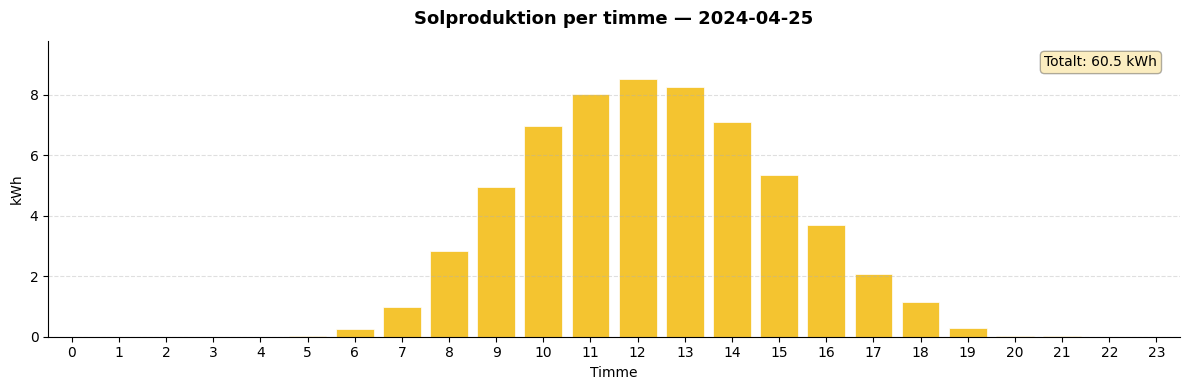

Sparad → demo_sol_2024-04-25.csv + .png


In [39]:
# Diagram 1: Solproduktion per timme

sol_df = pd.DataFrame({
    "Timme":   list(range(24)),
    "Sol_kWh": solar_24
})
sol_df.to_csv(f"{OUTPUT_DIR}/demo_sol_{DEMO_DATE}.csv", index=False, encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(12, 4))

colors = ['#F4C430' if v > 0 else '#CCCCCC' for v in solar_24]
ax.bar(range(24), solar_24, color=colors, edgecolor='white', linewidth=0.5)

ax.set_title(f"Solproduktion per timme — {DEMO_DATE}", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Timme")
ax.set_ylabel("kWh")
ax.set_xticks(range(24))
ax.set_xlim(-0.5, 23.5)
ax.set_ylim(0, max(solar_24) * 1.15)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

ax.annotate(f"Totalt: {solar_24.sum():.1f} kWh",
            xy=(0.98, 0.95), xycoords='axes fraction',
            ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', fc='#F4C430', alpha=0.3))

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/demo_sol_{DEMO_DATE}.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Sparad → demo_sol_{DEMO_DATE}.csv + .png")

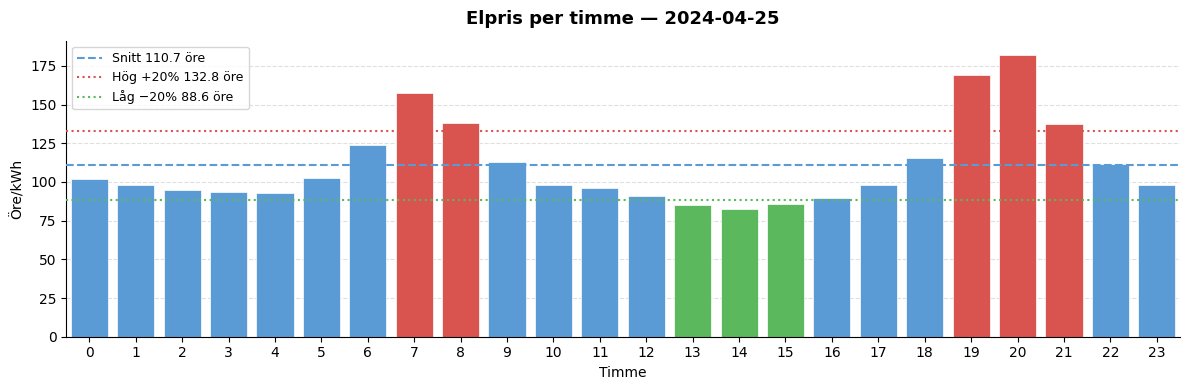

Sparad → demo_pris_2024-04-25.csv + .png


In [40]:
# Diagram 2: Elpris per timme med hög/låg-nivåer

pris_df = pd.DataFrame({
    "Timme":      list(range(24)),
    "Pris_ore":   prices_24,
    "Snitt":      avg_p,
    "Hög_gräns":  HIGH_PRICE,
    "Låg_gräns":  LOW_PRICE
})
pris_df.to_csv(f"{OUTPUT_DIR}/demo_pris_{DEMO_DATE}.csv", index=False, encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(12, 4))

bar_colors = ['#D9534F' if p >= HIGH_PRICE else ('#5CB85C' if p <= LOW_PRICE else '#5B9BD5')
              for p in prices_24]
ax.bar(range(24), prices_24, color=bar_colors, edgecolor='white', linewidth=0.5, zorder=2)

ax.axhline(avg_p,      color='#5B9BD5', linestyle='--', linewidth=1.5, label=f'Snitt {avg_p:.1f} öre', zorder=3)
ax.axhline(HIGH_PRICE, color='#D9534F', linestyle=':',  linewidth=1.5, label=f'Hög +20% {HIGH_PRICE:.1f} öre', zorder=3)
ax.axhline(LOW_PRICE,  color='#5CB85C', linestyle=':',  linewidth=1.5, label=f'Låg −20% {LOW_PRICE:.1f} öre', zorder=3)

ax.set_title(f"Elpris per timme — {DEMO_DATE}", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Timme")
ax.set_ylabel("Öre/kWh")
ax.set_xticks(range(24))
ax.set_xlim(-0.5, 23.5)
ax.legend(loc='upper left', fontsize=9, framealpha=0.8)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/demo_pris_{DEMO_DATE}.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Sparad → demo_pris_{DEMO_DATE}.csv + .png")

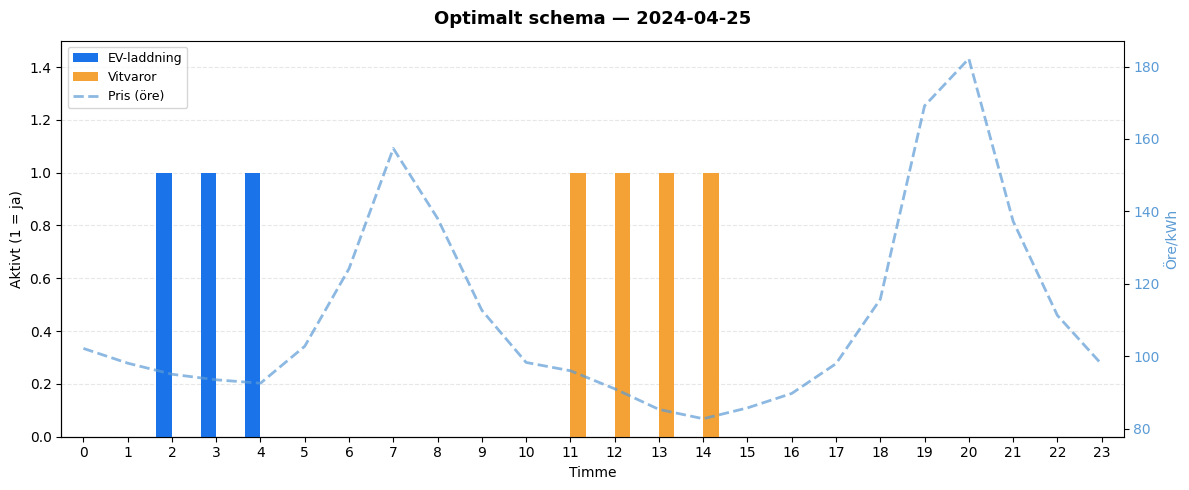

EV-timmar: [2, 3, 4]
Vitvaror-timmar: [11, 12, 13, 14]
Sparad → demo_schema_2024-04-25.csv + .png


In [41]:
# Diagram 3: Optimalt schema – EV och vitvaror

schema_df = pd.DataFrame({
    "Timme":    list(range(24)),
    "Pris_ore": prices_24,
    "Sol_kWh":  solar_24,
    "EV":       [1 if h in ev_hours else 0 for h in range(24)],
    "Vitvaror": [1 if h in best_app else 0 for h in range(24)]
})
schema_df.to_csv(f"{OUTPUT_DIR}/demo_schema_{DEMO_DATE}.csv", index=False, encoding='utf-8-sig')

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

# Priset som linje på höger axel
ax2.plot(range(24), prices_24, color='#5B9BD5', linewidth=2, linestyle='--',
         label='Pris (öre)', zorder=2, alpha=0.7)
ax2.set_ylabel("Öre/kWh", color='#5B9BD5')
ax2.tick_params(axis='y', labelcolor='#5B9BD5')

# Staplar: EV och vitvaror
width = 0.35
ev_bars  = ax1.bar([h - width/2 for h in range(24)],
                   [1 if h in ev_hours else 0 for h in range(24)],
                   width=width, color='#1A73E8', label='EV-laddning', zorder=3)
app_bars = ax1.bar([h + width/2 for h in range(24)],
                   [1 if h in best_app else 0 for h in range(24)],
                   width=width, color='#F4A235', label='Vitvaror', zorder=3)

ax1.set_title(f"Optimalt schema — {DEMO_DATE}", fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel("Timme")
ax1.set_ylabel("Aktivt (1 = ja)")
ax1.set_xticks(range(24))
ax1.set_xlim(-0.5, 23.5)
ax1.set_ylim(0, 1.5)
ax1.grid(axis='y', linestyle='--', alpha=0.3)
ax1.spines[['top', 'right']].set_visible(False)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9, framealpha=0.8)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/demo_schema_{DEMO_DATE}.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"EV-timmar: {sorted(ev_hours)}")
print(f"Vitvaror-timmar: {sorted(best_app)}")
print(f"Sparad → demo_schema_{DEMO_DATE}.csv + .png")

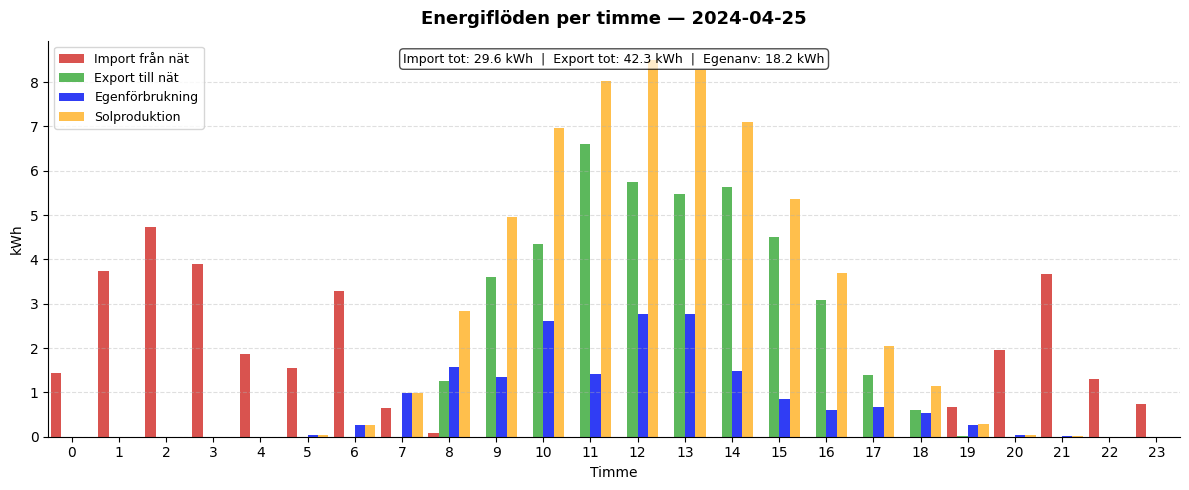

Sparad → demo_floden_2024-04-25.csv + .png


In [43]:
# Diagram 4: Energiflöden – import, export, egenförbrukning, sol

import_h  = [demo_data.loc[demo_data.index.hour == h, 'grid_import_kwh'].sum()  for h in range(24)]
export_h  = [demo_data.loc[demo_data.index.hour == h, 'grid_export_kwh'].sum()  for h in range(24)]
eigen_h   = [demo_data.loc[demo_data.index.hour == h, 'self_consumption_kwh'].sum() for h in range(24)]

flode_df = pd.DataFrame({
    "Timme":               list(range(24)),
    "Import_kWh":          import_h,
    "Export_kWh":          export_h,
    "Egenförbrukning_kWh": eigen_h,
    "Sol_kWh":             solar_24
})
flode_df.to_csv(f"{OUTPUT_DIR}/demo_floden_{DEMO_DATE}.csv", index=False, encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(12, 5))

width = 0.22
x = np.arange(24)
ax.bar(x - width*1.5, import_h,        width=width, color='#D9534F', label='Import från nät')
ax.bar(x - width*0.5, export_h,        width=width, color='#5CB85C', label='Export till nät')
ax.bar(x + width*0.5, eigen_h,         width=width, color="#303DF4", label='Egenförbrukning')
ax.bar(x + width*1.5, list(solar_24),  width=width, color='#FFA500', label='Solproduktion', alpha=0.7)

ax.set_title(f"Energiflöden per timme — {DEMO_DATE}", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Timme")
ax.set_ylabel("kWh")
ax.set_xticks(range(24))
ax.set_xlim(-0.5, 23.5)
ax.legend(loc='upper left', fontsize=9, framealpha=0.8)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

ax.annotate(f"Import tot: {sum(import_h):.1f} kWh  |  Export tot: {sum(export_h):.1f} kWh  |  Egenanv: {sum(eigen_h):.1f} kWh",
            xy=(0.5, 0.97), xycoords='axes fraction',
            ha='center', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/demo_floden_{DEMO_DATE}.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Sparad → demo_floden_{DEMO_DATE}.csv + .png")

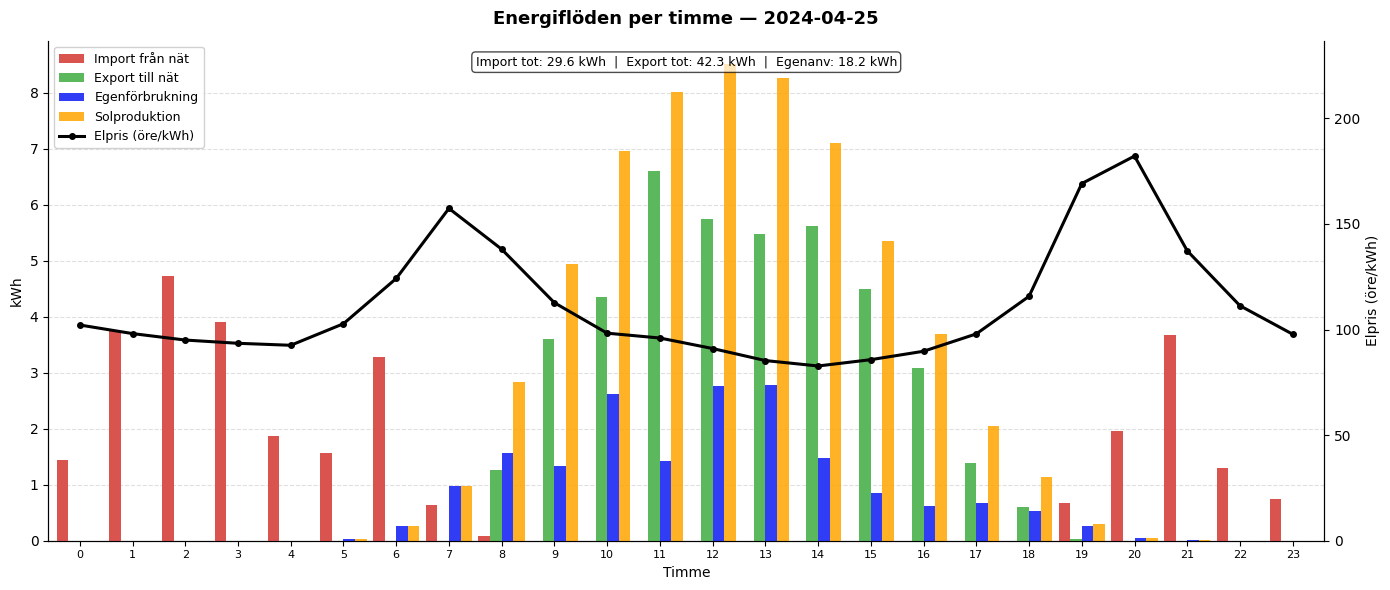

In [46]:
# Diagram 4: Energiflöden – import, export, egenförbrukning, sol

import_h  = [demo_data.loc[demo_data.index.hour == h, 'grid_import_kwh'].sum()  for h in range(24)]
export_h  = [demo_data.loc[demo_data.index.hour == h, 'grid_export_kwh'].sum()  for h in range(24)]
eigen_h   = [demo_data.loc[demo_data.index.hour == h, 'self_consumption_kwh'].sum() for h in range(24)]

flode_df = pd.DataFrame({
    "Timme":               list(range(24)),
    "Import_kWh":          import_h,
    "Export_kWh":          export_h,
    "Egenförbrukning_kWh": eigen_h,
    "Sol_kWh":             solar_24
})
flode_df.to_csv(f"{OUTPUT_DIR}/demo_floden_{DEMO_DATE}.csv", index=False, encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(14, 6))

# ── X-vektor och stapelbredd ───────────────────────────────────────────────────
width = 0.22
x = np.arange(24)   # 0–23, en vektor för ALLT

ax.bar(x - width*1.5, import_h,       width=width, color='#D9534F', label='Import från nät',  align='center', zorder=3)
ax.bar(x - width*0.5, export_h,       width=width, color='#5CB85C', label='Export till nät',  align='center', zorder=3)
ax.bar(x + width*0.5, eigen_h,        width=width, color='#303DF4', label='Egenförbrukning',  align='center', zorder=3)
ax.bar(x + width*1.5, list(solar_24), width=width, color='#FFA500', label='Solproduktion',    align='center', zorder=3, alpha=0.85)

# ── X-axeln: ticks exakt på 0–23 ──────────────────────────────────────────────
ax.set_xticks(x)                            # ← samma vektor som bar()
ax.set_xticklabels([str(h) for h in x], fontsize=8)
ax.set_xlim(-0.6, 23.6)


# ── Höger y-axel: elpris ──────────────────────────────────────────────────────
ax2 = ax.twinx()
ax2.plot(x, prices_24, color="#000000", linewidth=2.2, marker='o', markersize=4,
         label='Elpris (öre/kWh)', zorder=5)
ax2.set_ylabel("Elpris (öre/kWh)", fontsize=10, color="#000000")
ax2.tick_params(axis='y', labelcolor="#000000")
ax2.set_ylim(0, max(prices_24) * 1.3)
ax2.spines['right'].set_color("#000000")

# ── Gemensam legend för båda axlar ────────────────────────────────────────────
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2,
          loc='upper left', fontsize=9, framealpha=0.9)

# ── Övrig formatering ─────────────────────────────────────────────────────────
ax.set_title(f"Energiflöden per timme — {DEMO_DATE}", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Timme", fontsize=10)
ax.set_ylabel("kWh", fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
ax.spines[['top']].set_visible(False)
ax2.spines[['top']].set_visible(False)

ax.annotate(
    f"Import tot: {sum(import_h):.1f} kWh  |  Export tot: {sum(export_h):.1f} kWh  |  Egenanv: {sum(eigen_h):.1f} kWh",
    xy=(0.5, 0.97), xycoords='axes fraction',
    ha='center', va='top', fontsize=9,
    bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7)
)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/demo_floden_{DEMO_DATE}.png", dpi=150, bbox_inches='tight')
plt.show()


# Avslutning

Jag gick in i detta med bilden att jag skulle hitta ett beslutsstöd för hushållsbatteri, men upptäckte snabbt att det inte var mycket lönt. Däremot var det en ganska intressant resa i underlag och metodik för att skapa en styrning för ett smart hem

## Reflektion
Det är lätt att komma lite för "nära" ett sånt här projekt och innan jag går vidare tänkte jag nämna att man med ett lite mer översiktligt perspektiv kan se hur styrning av hushålls elförbrukning kan vara effektivt för spara pengar - men att den prediktiva modellen också kan användas för att kapa effekttoppar i elnätet och - i förlängningen - även vara miljövänligt eftersom den dyraste elen typiskt produceras av fossil spetskraft.

Just för miljöaspekten behöver man dock beakta att batterierna i sig innebär en betydande miljöskuld eftersom det både ska produceras och dessutom innehåller stora mängder rare earth-mineraler.  

I ett backtest kunde jag öka egenförbrukningsgraden från 27 % till 45 % under optimerade dagar. Det är förvisso lite "fusk" eftersom jag har facit på hand, men principen visar att större användning av egenproducerad solel faktiskt kan konsumeras lokalt och därmed minska behovet av att köpa el med dyra fasta kostnader. Det ger en stor besparing.

Eftersom den smarta modellen gör så stor nytta utan batteri minskar också orättvisan som annars ligger i att bara den som har kapital kan tjäna pengar på de olika delarna av den "gröna omställningen". Solpaneler och batterier i all ära - men att bara styra om konsumtion till timmar (kvartar numera) med lägre elpris kan göra stor nytta utan någon större investering. Modellen ger rekommendationer som man förvisso då får följa manuellt - men det är inte svårt att göra.

Det man kanske kan reflektera över också är att om min (eller andras) smarta modeller används i större utsträckning uppstår en synkroniseringseffekt där alla laddar sina batterier och vitvaror under exakt samma billiga timmar och alla urladdas under exakt samma dyra timmar. Det innebär då paradoxalt nog att just dessa billiga och dyra timmar "försvinner" och plattar ut spotpriset så att den ekonomiska nyttan minskar. 

Det kan också vara värt att nämna att såna här synkroniseringseffekter också kan leda till nya toppar som elleverantörerna kan ha svårt att bedöma. Det får dock vara en fråga som ligger utanför min rapport här.


### IoT, API:er och Fallbacks
Min modell är byggd på historiska IoT-data från mina solpaneler och när den arbetar så bygger den i sin tur på flera externa API:er: SMHI STRÅNG (solinstrålning), SMHI metobs (temperatur), Nordpool/Entso-E (spotpris) och SMHI SNOW1G (väderprognoser) - som i sin tur i flera delar bygger på IoT-data. 

Om någon av prognoserna skulle vara otillgängliga får systemet hantera det med interpolation, historiska medelpriser och konservativa strategier samt en neutral bedömning av vädret om prognos saknas. Just väderprognosens kvalitet är den viktigaste punkten där en falsk positiv prognos ger ett urladdat batteri som kräver inköp av dyr el när priset är högt. Backtestet visar att det här faktiskt inträffar då och då, och att det har en icke obetydlig påverkan på priset.

###  Modellens begränsningar 
Det finns stor risk för overfitting — modellen är tränad på mitt specifika hus, mina solpaneler, min geografi. Den kan därför inte generalisera direkt till andra hushåll.

PuLP-modellen förutsätter att priserna och produktionen är kända i förväg. I verklig drift finns bara  prognoser att tillgå och inte det facit som jag arbetat med. Det gör att backtest ger extremt optimistiska resultat, varför dessa får tas med en nypa salt.

Modellen är också i sin nuvarande form för statisk. Den vet inte när jag faktiskt är hemma, om jag vill ha varmvattnet klart till 07:00 eller om jag verkligen behöver köra iväg med bilen den aktuella dagen. I en verklig implementering skulle modellen få fortsätta lära sig dag för dag och hitta de mönster som ytterligare kan få den predikterade kurvan snävare mot verkligheten.

Modellen skulle också behöva förses med en säkerhetsventil i form av realtidsfeedback. Om molnet oväntat skymmer solen tvärt emot väderprognosen skulle en mekanism för omplanering under pågående dag göra stor nytta.

### Integritetsfrågan

Som nämnts på föreläsningen är IoT inte utan fallgropar. Just integritet är en sådan, där en hög tidsmässig upplösning på elförbrukningsdata kan avslöja betydligt mer än man kunde tro. Enligt min research kan NILM (Non-Intrusive Load Monitoring) identifiera enskilda apparater utifrån deras  effektsignaturer. Bl.a. kan nämnas en diskmaskin som har ett unikt cykelformat  medan en elbilsladdare syns som ett rektangulärt block och en ugn som brant stegfunktion.

Även detta får lämnas därhän i min rapport, men man blir ändå lite eftertänksam när man upptäcker hur mycket av ens levnadsmönster som avslöjas av något så enkelt. 

### Affärsmässiga möjligheter

Det här har ju varit en övning i liten skala, men principen kan skalas upp av energibolag/aggregatorer som med en "Virtual Power Plant" skulle kunna samla ihop hundratals såna här hushållsmodeller och handla balanskapacitet på frekvensregleringsmarknaden. Det här är ju den affärsmodell som t.ex. Tibber och Charge Amps arbetar med.

Ett annat alternativ är fastighetsbolag som kan använda en skalad version av modellen för att sänka abonnemangsnivå (lägre fast pris med lägre säkringsampere - och effekttarifferna är kanske inte permanent stoppade?). Den besparing som en smart styrning ges kan delas med hyresgästerna för att få med dem på tåget.

Om integritetskravet uppfylls kan en aggregerad datainsamling med anonymiserad förbrukningsdata vara av stort värde för elnätbolagens kapacitetsplanering.


### Vad som kunde gjorts annorlunda
Med Reinforcement learning istället för regelbaserad optimering skulle en agent kunna lära sig av faktiska utfall och gradvis förbättra sina beslut.

AI-modelleringen kunde också gjorts med en ensemble för att kombinera prognoser med satellitdata. Detta gör dock SNOW1G på ett rimligt bra sätt och kanske inte är så viktigt.

Slutligen skulle modellen egentligen byggts för 15-minutersperioder eftersom dessa faktiskt fanns tillgängliga i flera delar (och solinstrålningsprognoserna kunde delats upp i fyra delar per timme).

## Sammanfattning

Mitt projekt demonstrerar att en AI-styrning av ett smart hem inte behöver vara så komplicerad. OK, jag skrev om det där själv. Kan du granska texten nedan där jag även inkluderat affärsmässiga möjligheter och vad som kunde gjorts annorlunda - och säga om jag nu uppfyller kunskapskravet?



# Avslutning



Jag gick in i detta med bilden att jag skulle hitta ett beslutsstöd för hushållsbatteri, men upptäckte snabbt att det inte var mycket lönt. Däremot var det en ganska intressant resa i underlag och metodik för att skapa en styrning för ett smart hem



## Reflektion

Det är lätt att komma lite för "nära" ett sånt här projekt och innan jag går vidare tänkte jag nämna att man med ett lite mer översiktligt perspektiv kan se hur styrning av hushålls elförbrukning kan vara effektivt för spara pengar - men att den prediktiva modellen också kan användas för att kapa effekttoppar i elnätet och - i förlängningen - även vara miljövänligt eftersom den dyraste elen typiskt produceras av fossil spetskraft.



Just för miljöaspekten behöver man dock beakta att batterierna i sig innebär en betydande miljöskuld eftersom det både ska produceras och dessutom innehåller stora mängder rare earth-mineraler.  



I ett backtest kunde jag öka egenförbrukningsgraden från 27 % till 45 % under optimerade dagar. Det är förvisso lite "fusk" eftersom jag har facit på hand, men principen visar att större användning av egenproducerad solel faktiskt kan konsumeras lokalt och därmed minska behovet av att köpa el med dyra fasta kostnader. Det ger en stor besparing.



Eftersom den smarta modellen gör så stor nytta utan batteri minskar också orättvisan som annars ligger i att bara den som har kapital kan tjäna pengar på de olika delarna av den "gröna omställningen". Solpaneler och batterier i all ära - men att bara styra om konsumtion till timmar (kvartar numera) med lägre elpris kan göra stor nytta utan någon större investering. Modellen ger rekommendationer som man förvisso då får följa manuellt - men det är inte svårt att göra.



Det man kanske kan reflektera över också är att om min (eller andras) smarta modeller används i större utsträckning uppstår en synkroniseringseffekt där alla laddar sina batterier och vitvaror under exakt samma billiga timmar och alla urladdas under exakt samma dyra timmar. Det innebär då paradoxalt nog att just dessa billiga och dyra timmar "försvinner" och plattar ut spotpriset så att den ekonomiska nyttan minskar. 



Det kan också vara värt att nämna att såna här synkroniseringseffekter också kan leda till nya toppar som elleverantörerna kan ha svårt att bedöma. Det får dock vara en fråga som ligger utanför min rapport här.





### IoT, API:er och fallbacks



Kan du kombinera de här texterna till några sammanhängande stycken om modellen? 



### IoT, API:er och Fallbacks

Min modell är byggd på historiska IoT-data från mina solpaneler och när den arbetar så bygger den i sin tur på flera externa API:er: SMHI STRÅNG (solinstrålning), SMHI metobs (temperatur), Nordpool/Entso-E (spotpris) och SMHI SNOW1G (väderprognoser) - som i sin tur i flera delar bygger på IoT-data. 



Om någon av prognoserna skulle vara otillgängliga får systemet hantera det med interpolation, historiska medelpriser och konservativa strategier samt en neutral bedömning av vädret om prognos saknas. Just väderprognosens kvalitet är den viktigaste punkten där en falsk positiv prognos ger ett urladdat batteri som kräver inköp av dyr el när priset är högt. Backtestet visar att det här faktiskt inträffar då och då, och att det har en icke obetydlig påverkan på priset.



###  Modellens begränsningar 

Det finns stor risk för overfitting — modellen är tränad på mitt specifika hus, mina solpaneler, min geografi. Den kan därför inte generalisera direkt till andra hushåll.



PuLP-modellen förutsätter att priserna och produktionen är kända i förväg. I verklig drift finns bara  prognoser att tillgå och inte det facit som jag arbetat med. Det gör att backtest ger extremt optimistiska resultat, varför dessa uteslutits ur rapporten.



Modellen är också i sin nuvarande form för statisk. Den vet inte när jag faktiskt är hemma, om jag vill ha varmvattnet klart till 07:00 eller om jag verkligen behöver köra iväg med bilen den aktuella dagen. I en verklig implementering skulle modellen få fortsätta lära sig dag för dag och hitta de mönster som ytterligare kan få den predikterade kurvan snävare mot verkligheten.



Modellen skulle också behöva förses med en säkerhetsventil i form av realtidsfeedback. Om molnet oväntat skymmer solen tvärt emot väderprognosen skulle en mekanism för omplanering under pågående dag göra stor nytta.



### Integritetsfrågan



Som nämnts på föreläsningen är IoT inte utan fallgropar. Just integritet är en sådan, där en hög tidsmässig upplösning på elförbrukningsdata kan avslöja betydligt mer än man kunde tro. Enligt min research kan NILM (Non-Intrusive Load Monitoring) identifiera enskilda apparater utifrån deras  effektsignaturer. Bl.a. kan nämnas en diskmaskin som har ett unikt cykelformat  medan en elbilsladdare syns som ett rektangulärt block och en ugn som brant stegfunktion.



Även detta får lämnas därhän i min rapport, men man blir ändå lite eftertänksam när man upptäcker hur mycket av ens levnadsmönster som avslöjas av något så enkelt. 



### Affärsmässiga möjligheter



Det här har ju varit en övning i liten skala, men principen kan skalas upp av energibolag/aggregatorer som med en "Virtual Power Plant" skulle kunna samla ihop hundratals såna här hushållsmodeller och handla balanskapacitet på frekvensregleringsmarknaden. Det här är ju den affärsmodell som t.ex. Tibber och Charge Amps arbetar med.



Ett annat alternativ är fastighetsbolag som kan använda en skalad version av modellen för att sänka abonnemangsnivå (lägre fast pris med lägre säkringsampere - och effekttarifferna är kanske inte permanent stoppade?). Den besparing som en smart styrning ges kan delas med hyresgästerna för att få med dem på tåget.



Om integritetskravet uppfylls kan en aggregerad datainsamling med anonymiserad förbrukningsdata vara av stort värde för elnätbolagens kapacitetsplanering.





### Vad som kunde gjorts annorlunda

Med Reinforcement learning istället för regelbaserad optimering skulle en agent kunna lära sig av faktiska utfall och gradvis förbättra sina beslut.



AI-modelleringen kunde också gjorts med en ensemble för att kombinera prognoser med satellitdata. Detta gör dock SNOW1G på ett rimligt bra sätt och kanske inte är så viktigt.



Slutligen skulle modellen egentligen byggts för 15-minutersperioder eftersom dessa faktiskt fanns tillgängliga i flera delar (och solinstrålningsprognoserna kunde delats upp i fyra delar per timme).



## Sammanfattning

Mitt projekt demonstrerar att AI-styrning av ett smart hem inte behöver vara så komplicerad — och att den faktiskt gör stor nytta även utan det dyra batteri som ofta säljs in som förutsättning. Det mest intressanta med resan har kanske ändå inte varit besparingen i sig, utan insikten om hur mycket systemtänkande som krävs. Min modell kan fungera perfekt för vårt hushåll, men kanske är helt värdelös för ett annat, bra väderprognosdagar i backtestet döljer dagar då prognosen faktiskt var fel samt att en tillräckligt utbredd smart styrning paradoxalt nog urholkar sin egen ekonomiska nytta.

Ett naturligt nästa steg vore att integrera modellen som "hjärna" i hemmet — antingen som ett beslutsstöd att följa manuellt, eller som en faktisk styrning av elbilsladdning, varmvatten och andra förbrukare som kan flyttas i tid. Eftersom batteriet har begränsad nytta i relation till investeringskostnaden kan man dessutom bidra till en grönare och mer rättvis energiomställning utan att behöva fylla garaget med brandfarliga litiumceller.
